In [5]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import re
import ast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

DATA_PATH = Path("/content/guests.csv")
TRAINING_NOTEBOOK_PATH = Path("/mnt/data/01_train_weather_tft_prod_calendar_8weeks.ipynb")

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

print("DATA_PATH:", DATA_PATH)
print("TRAINING_NOTEBOOK_PATH:", TRAINING_NOTEBOOK_PATH)

DATA_PATH: /content/guests.csv
TRAINING_NOTEBOOK_PATH: /mnt/data/01_train_weather_tft_prod_calendar_8weeks.ipynb


## 1. Сверка признаков с training notebook

Сначала фиксируем, какие признаки реально используются при обучении TFT. Это важно для презентации: мы показываем не абстрактные EDA-фичи, а именно те признаки, на которых далее может обучаться модель.

**Проверка:** `month_sin` и `month_cos` в training notebook отсутствуют.

In [6]:
# Exact feature groups from the training notebook.
# These lists are intentionally copied 1:1 from 01_train_weather_tft_prod_calendar_8weeks.ipynb.

BASELINE_KNOWN_CATEGORICALS = [
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
]

BASELINE_KNOWN_REALS = [
    "day_of_month",
    "weekofyear",
    "year",
]

HOLIDAY_KNOWN_CATEGORICALS = [
    "is_holiday",
    "is_preholiday",
    "is_shortened_day",
    "is_official_day_off",
    "is_working_weekend",
    "is_transferred_day_off",
    "is_moscow_city_holiday",
    "is_may_holidays_period",
    "production_day_type",
    "holiday_name",
]

HOLIDAY_KNOWN_REALS = [
    "long_weekend_day_number",
    "hour_x_holiday",
    "hour_x_preholiday",
    "hour_x_official_day_off",
    "hour_x_working_weekend",
]

WEATHER_KNOWN_CATEGORICALS = [
    "weather_code",
    "is_day",
    "has_precipitation",
    "has_rain",
    "has_snowfall",
    "is_cloudy",
    "is_windy",
    "precipitation_level",
    "temperature_bin",
]

WEATHER_KNOWN_REALS = [
    "temperature_2m",
    "apparent_temperature",
    "precipitation",
    "rain",
    "snowfall",
    "relative_humidity_2m",
    "cloud_cover",
    "wind_speed_10m",
    "wind_gusts_10m",
    "hour_x_precipitation",
    "hour_x_temperature",
]

TIME_VARYING_KNOWN_CATEGORICALS = list(dict.fromkeys(
    BASELINE_KNOWN_CATEGORICALS + HOLIDAY_KNOWN_CATEGORICALS + WEATHER_KNOWN_CATEGORICALS
))
TIME_VARYING_KNOWN_REALS = list(dict.fromkeys(
    BASELINE_KNOWN_REALS + HOLIDAY_KNOWN_REALS + WEATHER_KNOWN_REALS
))
TIME_VARYING_UNKNOWN_REALS = ["guests_count"]
STATIC_CATEGORICALS = ["restaurant"]
GROUP_IDS = ["restaurant", "segment_id"]

all_training_features = (
    STATIC_CATEGORICALS + GROUP_IDS
    + TIME_VARYING_KNOWN_CATEGORICALS
    + TIME_VARYING_KNOWN_REALS
    + TIME_VARYING_UNKNOWN_REALS
)

for forbidden in ["month_sin", "month_cos"]:
    print(f"{forbidden} in training features?", forbidden in all_training_features)

feature_manifest = pd.DataFrame({
    "feature_group": (
        ["static_categorical"] * len(STATIC_CATEGORICALS)
        + ["group_id"] * len(GROUP_IDS)
        + ["known_categorical"] * len(TIME_VARYING_KNOWN_CATEGORICALS)
        + ["known_real"] * len(TIME_VARYING_KNOWN_REALS)
        + ["unknown_real_target"] * len(TIME_VARYING_UNKNOWN_REALS)
    ),
    "feature": all_training_features,
}).drop_duplicates()

display(feature_manifest)
print("Total unique configured fields:", feature_manifest["feature"].nunique())

month_sin in training features? False
month_cos in training features? False


,feature_group,feature
0,static_categorical,restaurant
1,group_id,restaurant
2,group_id,segment_id
3,known_categorical,hour
4,known_categorical,day_of_week
5,known_categorical,month
6,known_categorical,is_weekend
7,known_categorical,is_holiday
8,known_categorical,is_preholiday
9,known_categorical,is_shortened_day


Total unique configured fields: 45


## 2. Загрузка данных и приведение к часовому ряду

В исходных данных одна строка — это количество гостей за конкретный рабочий час. Training notebook использует рабочие часы **07:00–22:00**, поэтому здесь сохраняем тот же диапазон.

In [7]:
BUSINESS_START_HOUR = 7
BUSINESS_END_HOUR = 22

raw = pd.read_csv(DATA_PATH)
raw["sale_date"] = pd.to_datetime(raw["sale_date"]).dt.normalize()
raw["sale_hour"] = pd.to_numeric(raw["sale_hour"], errors="raise").astype(int)
raw["guests_count"] = pd.to_numeric(raw["guests_count"], errors="coerce")
raw["timestamp"] = raw["sale_date"] + pd.to_timedelta(raw["sale_hour"], unit="h")

df = (
    raw.groupby("timestamp", as_index=False)["guests_count"]
    .sum()
    .sort_values("timestamp")
    .reset_index(drop=True)
)
df["sale_date"] = df["timestamp"].dt.normalize()
df["sale_hour"] = df["timestamp"].dt.hour
df = df[df["sale_hour"].between(BUSINESS_START_HOUR, BUSINESS_END_HOUR)].copy()

print("Raw rows:", len(raw))
print("Hourly aggregated business rows:", len(df))
print("Date range:", df["sale_date"].min().date(), "..", df["sale_date"].max().date())
print("Hours:", sorted(df["sale_hour"].unique()))
display(df.head())

Raw rows: 40543
Hourly aggregated business rows: 40543
Date range: 2019-01-02 .. 2026-04-26
Hours: [np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22)]


,timestamp,guests_count,sale_date,sale_hour
0,2019-01-02 07:00:00,5,2019-01-02,7
1,2019-01-02 08:00:00,11,2019-01-02,8
2,2019-01-02 09:00:00,14,2019-01-02,9
3,2019-01-02 10:00:00,17,2019-01-02,10
4,2019-01-02 11:00:00,28,2019-01-02,11


## 3. Проверка чистоты данных

Что демонстрируем: ряд регулярный, таргет числовой, дубликатов после агрегации нет, рабочие часы совпадают с training notebook, а пропуски внутри непрерывных сегментов можно контролируемо обработать так же, как в обучении.

,metric,value
0,rows_after_hourly_aggregation,40543.000000
1,duplicate_timestamps_after_aggregation,0.000000
2,null_target_rows_after_aggregation,0.000000
3,negative_target_rows,0.000000
4,business_hour_min,7.000000
5,business_hour_max,22.000000
6,continuous_segments,5.000000
7,missing_business_hours_inside_segments_filled_...,273.000000
8,missing_share_inside_segments,0.006689


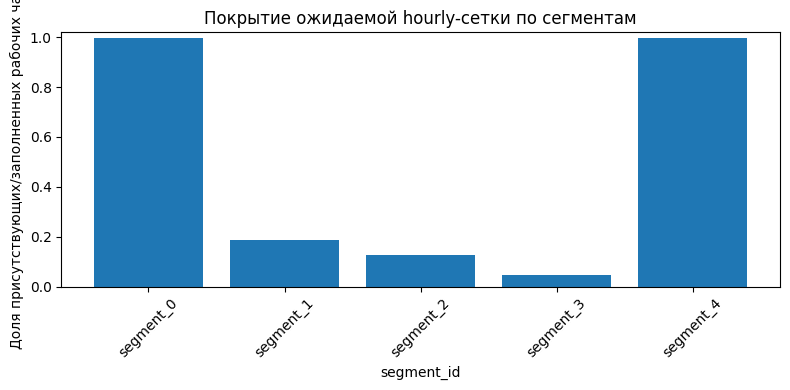

**Вывод для презентации.** После агрегации нет дубликатов timestamp. Ряд приводится к регулярной hourly-сетке 07:00–22:00. Большие разрывы не склеиваются в один ряд, а отделяются через `segment_id`, что совпадает с логикой training notebook и снижает риск искусственных переходов между режимами.

In [8]:
# Build expected business-hour grid by continuous segments, matching training logic: gaps > 14 days create a new segment.
df = df.sort_values("timestamp").reset_index(drop=True)
gap = df["timestamp"].diff()
df["segment_id"] = (gap > pd.Timedelta("14D")).cumsum().astype(int)
df["segment_id"] = "segment_" + df["segment_id"].astype(str)

def make_business_hour_grid(min_date, max_date):
    dates = pd.date_range(pd.Timestamp(min_date).normalize(), pd.Timestamp(max_date).normalize(), freq="D")
    hours = range(BUSINESS_START_HOUR, BUSINESS_END_HOUR + 1)
    rows = [d + pd.Timedelta(hours=h) for d in dates for h in hours]
    out = pd.DataFrame({"timestamp": rows})
    out["sale_date"] = out["timestamp"].dt.normalize()
    out["sale_hour"] = out["timestamp"].dt.hour
    return out

aligned_parts = []
for segment_id, part in df.groupby("segment_id", sort=True):
    grid = make_business_hour_grid(part["sale_date"].min(), part["sale_date"].max())
    grid["segment_id"] = segment_id
    merged = grid.merge(part[["timestamp", "guests_count"]], on="timestamp", how="left")
    merged["was_missing_inside_segment"] = merged["guests_count"].isna()
    merged["guests_count"] = merged["guests_count"].fillna(0.0)
    aligned_parts.append(merged)

aligned = pd.concat(aligned_parts, ignore_index=True).sort_values(["segment_id", "timestamp"]).reset_index(drop=True)

quality = pd.DataFrame({
    "metric": [
        "rows_after_hourly_aggregation",
        "duplicate_timestamps_after_aggregation",
        "null_target_rows_after_aggregation",
        "negative_target_rows",
        "business_hour_min",
        "business_hour_max",
        "continuous_segments",
        "missing_business_hours_inside_segments_filled_with_zero",
        "missing_share_inside_segments",
    ],
    "value": [
        len(df),
        int(df["timestamp"].duplicated().sum()),
        int(df["guests_count"].isna().sum()),
        int((df["guests_count"] < 0).sum()),
        int(df["sale_hour"].min()),
        int(df["sale_hour"].max()),
        int(df["segment_id"].nunique()),
        int(aligned["was_missing_inside_segment"].sum()),
        float(aligned["was_missing_inside_segment"].mean()),
    ]
})
display(quality)

fig, ax = plt.subplots(figsize=(8, 4))
segment_counts = aligned.groupby("segment_id")["was_missing_inside_segment"].agg(["count", "sum"])
segment_counts["present_share"] = 1 - segment_counts["sum"] / segment_counts["count"]
ax.bar(segment_counts.index, segment_counts["present_share"])
ax.set_title("Покрытие ожидаемой hourly-сетки по сегментам")
ax.set_xlabel("segment_id")
ax.set_ylabel("Доля присутствующих/заполненных рабочих часов")
ax.set_ylim(0, 1.02)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(Markdown("""**Вывод для презентации.** После агрегации нет дубликатов timestamp. Ряд приводится к регулярной hourly-сетке 07:00–22:00. Большие разрывы не склеиваются в один ряд, а отделяются через `segment_id`, что совпадает с логикой training notebook и снижает риск искусственных переходов между режимами."""))

## 4. Вырезанные периоды и clean dataset

Ниже используются те же периоды вырезания, что и в ноутбуке чистки. Для анализа прошлых лет окно 27.04–03.05 берется **только из clean-части**.

In [9]:
BAD_PERIODS = [
    ("2020-03-15", "2020-06-30", "covid_main_drop"),
    ("2020-07-01", "2020-08-31", "covid_recovery"),
    ("2021-06-28", "2021-07-18", "qr_restrictions"),
    ("2021-10-28", "2021-11-07", "oct_2021_non_working_days"),
    ("2022-03-08", "2022-06-11", "mcdonalds_suspended"),
    ("2022-06-12", "2022-08-31", "rebrand_ramp"),
]
DROP_PERIODS = [name for _, _, name in BAD_PERIODS]

aligned["period_type"] = "normal"
for start, end, name in BAD_PERIODS:
    mask = aligned["sale_date"].between(pd.Timestamp(start), pd.Timestamp(end))
    aligned.loc[mask, "period_type"] = name
aligned.loc[aligned["sale_date"] >= pd.Timestamp("2022-09-01"), "period_type"] = "post_rebrand_normal"

clean_df = aligned[~aligned["period_type"].isin(DROP_PERIODS)].copy()

period_summary = aligned.groupby("period_type", as_index=False).agg(
    rows=("timestamp", "count"),
    date_min=("sale_date", "min"),
    date_max=("sale_date", "max"),
    guests_sum=("guests_count", "sum"),
)
period_summary["date_min"] = period_summary["date_min"].dt.date
period_summary["date_max"] = period_summary["date_max"].dt.date
display(period_summary.sort_values("date_min"))

print("Rows before cleaning:", len(aligned))
print("Rows after cleaning:", len(clean_df))
print("Removed rows:", len(aligned) - len(clean_df))
print("Removed share:", round(1 - len(clean_df) / len(aligned), 4))

,period_type,rows,date_min,date_max,guests_sum
3,normal,15344,2019-01-02,2022-03-07,1650234.0
0,covid_main_drop,1728,2020-03-15,2020-06-30,94611.0
1,covid_recovery,992,2020-07-01,2020-08-31,84285.0
6,qr_restrictions,336,2021-06-28,2021-07-18,26066.0
4,oct_2021_non_working_days,176,2021-10-28,2021-11-07,11021.0
2,mcdonalds_suspended,160,2022-03-08,2022-05-24,13397.0
7,rebrand_ramp,736,2022-06-30,2022-08-31,29939.0
5,post_rebrand_normal,21344,2022-09-01,2026-04-26,2298394.0


Rows before cleaning: 40816
Rows after cleaning: 36688
Removed rows: 4128
Removed share: 0.1011


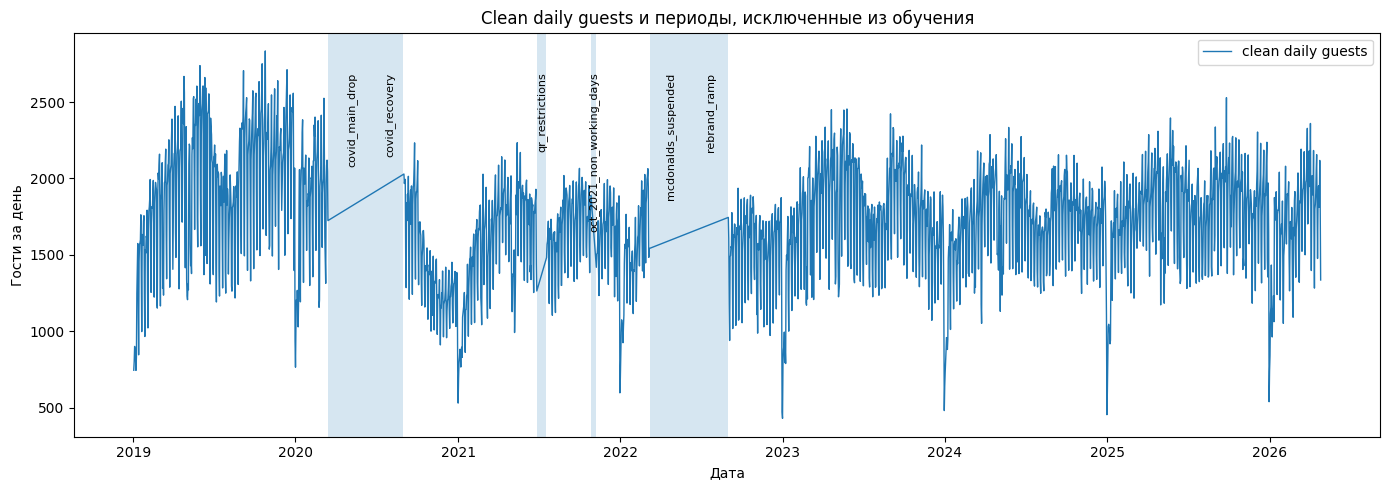

**Вывод для презентации.** Мы не обучаем модель на периодах с внешними режимными сдвигами: COVID-ограничения, QR/нерабочие дни и переходный период suspend/rebrand. Это делает обучающий ряд ближе к нормальному спросу и снижает риск того, что модель выучит нерелевантные исторические шоки.

In [10]:
daily = aligned.groupby(["sale_date", "period_type"], as_index=False)["guests_count"].sum()
clean_daily = clean_df.groupby("sale_date", as_index=False)["guests_count"].sum()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(clean_daily["sale_date"], clean_daily["guests_count"], linewidth=1, label="clean daily guests")

# Shade removed periods.
for start, end, name in BAD_PERIODS:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.18)
    mid = pd.Timestamp(start) + (pd.Timestamp(end) - pd.Timestamp(start)) / 2
    ax.text(mid, clean_daily["guests_count"].max() * 0.95, name, rotation=90, va="top", ha="center", fontsize=8)

ax.set_title("Clean daily guests и периоды, исключенные из обучения")
ax.set_xlabel("Дата")
ax.set_ylabel("Гости за день")
ax.legend()
plt.tight_layout()
plt.show()

display(Markdown("""**Вывод для презентации.** Мы не обучаем модель на периодах с внешними режимными сдвигами: COVID-ограничения, QR/нерабочие дни и переходный период suspend/rebrand. Это делает обучающий ряд ближе к нормальному спросу и снижает риск того, что модель выучит нерелевантные исторические шоки."""))

## 5. Признаки, совпадающие с training notebook

Создаем только те календарные и holiday-признаки, которые есть в training notebook. Weather-признаки также присутствуют в списке training features, но в этом EDA-ноутбуке они не восстанавливаются из внешнего API, чтобы не смешивать анализ таргета с загрузкой погоды. Для обучения они добавляются в training pipeline.

In [11]:
FEDERAL_HOLIDAY_NAMES = {
    (1, 1): "new_year", (1, 2): "new_year_holidays", (1, 3): "new_year_holidays", (1, 4): "new_year_holidays",
    (1, 5): "new_year_holidays", (1, 6): "new_year_holidays", (1, 7): "christmas", (1, 8): "new_year_holidays",
    (2, 23): "defender_of_fatherland_day", (3, 8): "international_womens_day", (5, 1): "spring_and_labor_day",
    (5, 9): "victory_day", (6, 12): "russia_day", (11, 4): "national_unity_day",
}

OFFICIAL_RU_CALENDAR_OVERRIDES = {
    2023: {
        "dayoff": ["0101", "0102", "0103", "0104", "0105", "0106", "0107", "0108", "0223", "0224", "0308", "0501", "0508", "0509", "0612", "1106"],
        "predayoff": ["0222", "0307", "1103"], "workday": [],
        "holiday": ["0101", "0102", "0103", "0104", "0105", "0106", "0107", "0108", "0223", "0308", "0501", "0509", "0612", "1104"],
    },
    2024: {
        "dayoff": ["0101", "0102", "0103", "0104", "0105", "0106", "0107", "0108", "0223", "0308", "0429", "0430", "0501", "0509", "0510", "0612", "1104", "1230", "1231"],
        "predayoff": ["0222", "0307", "0508", "0611", "1102"], "workday": ["0427", "1102", "1228"],
        "holiday": ["0101", "0102", "0103", "0104", "0105", "0106", "0107", "0108", "0223", "0308", "0501", "0509", "0612", "1104"],
    },
    2025: {
        "dayoff": ["0101", "0102", "0103", "0104", "0105", "0106", "0107", "0108", "0501", "0502", "0508", "0509", "0612", "0613", "1103", "1104", "1231"],
        "predayoff": ["0307", "0430", "0611", "1101"], "workday": ["1101"],
        "holiday": ["0101", "0102", "0103", "0104", "0105", "0106", "0107", "0108", "0223", "0308", "0501", "0509", "0612", "1104"],
    },
    2026: {
        "dayoff": ["0101", "0102", "0103", "0104", "0105", "0106", "0107", "0108", "0109", "0110", "0111", "0223", "0309", "0501", "0511", "0612", "1104", "1231"],
        "predayoff": ["0430", "0508", "0611", "1103"], "workday": [],
        "holiday": ["0101", "0102", "0103", "0104", "0105", "0106", "0107", "0108", "0223", "0308", "0501", "0509", "0612", "1104"],
    },
}

def add_training_calendar_features(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    out["timestamp"] = pd.to_datetime(out["timestamp"])
    out["sale_date"] = pd.to_datetime(out["sale_date"]).dt.normalize()
    out["restaurant"] = "vkusno_i_tochka"
    out["date"] = out["timestamp"].dt.date
    out["hour"] = out["timestamp"].dt.hour
    out["day_of_week"] = out["timestamp"].dt.dayofweek
    out["day_of_month"] = out["timestamp"].dt.day
    out["month"] = out["timestamp"].dt.month
    out["year"] = out["timestamp"].dt.year
    out["weekofyear"] = out["timestamp"].dt.isocalendar().week.astype(int)
    out["is_weekend"] = out["day_of_week"].isin([5, 6]).astype(int)

    # Production calendar approximation aligned with names in training notebook.
    mmdd = out["sale_date"].dt.strftime("%m%d")
    years = out["sale_date"].dt.year
    is_override_dayoff = np.zeros(len(out), dtype=bool)
    is_override_predayoff = np.zeros(len(out), dtype=bool)
    is_override_workday = np.zeros(len(out), dtype=bool)
    is_override_holiday = np.zeros(len(out), dtype=bool)
    for y, spec in OFFICIAL_RU_CALENDAR_OVERRIDES.items():
        ym = years.eq(y)
        is_override_dayoff |= (ym & mmdd.isin(spec.get("dayoff", []))).to_numpy()
        is_override_predayoff |= (ym & mmdd.isin(spec.get("predayoff", []))).to_numpy()
        is_override_workday |= (ym & mmdd.isin(spec.get("workday", []))).to_numpy()
        is_override_holiday |= (ym & mmdd.isin(spec.get("holiday", []))).to_numpy()

    fixed_holiday = out.apply(lambda r: (int(r["month"]), int(r["day_of_month"])) in FEDERAL_HOLIDAY_NAMES, axis=1)
    out["holiday_name"] = out.apply(lambda r: FEDERAL_HOLIDAY_NAMES.get((int(r["month"]), int(r["day_of_month"])), "none"), axis=1)
    out["is_holiday"] = (fixed_holiday | is_override_holiday).astype(int)
    out["is_preholiday"] = is_override_predayoff.astype(int)
    out["is_shortened_day"] = out["is_preholiday"]
    out["is_working_weekend"] = is_override_workday.astype(int)
    out["is_official_day_off"] = ((out["is_weekend"].eq(1) | is_override_dayoff) & ~is_override_workday).astype(int)
    out["is_transferred_day_off"] = (is_override_dayoff & ~fixed_holiday.to_numpy()).astype(int)
    out["is_moscow_city_holiday"] = 0
    out["is_may_holidays_period"] = ((out["month"].eq(4) & out["day_of_month"].ge(27)) | (out["month"].eq(5) & out["day_of_month"].le(12))).astype(int)
    out["production_day_type"] = np.select(
        [out["is_working_weekend"].eq(1), out["is_shortened_day"].eq(1), out["is_official_day_off"].eq(1)],
        ["working_weekend", "shortened_day", "official_day_off"],
        default="working_day",
    )

    # Long weekend day number: sequence number inside consecutive official days off, else 0.
    day_flags = out[["sale_date", "is_official_day_off"]].drop_duplicates().sort_values("sale_date")
    day_flags["block"] = (day_flags["is_official_day_off"].ne(day_flags["is_official_day_off"].shift()) | (day_flags["sale_date"].diff() > pd.Timedelta(days=1))).cumsum()
    day_flags["long_weekend_day_number"] = day_flags.groupby("block").cumcount() + 1
    day_flags.loc[day_flags["is_official_day_off"].eq(0), "long_weekend_day_number"] = 0
    out = out.merge(day_flags[["sale_date", "long_weekend_day_number"]], on="sale_date", how="left")
    out["long_weekend_day_number"] = out["long_weekend_day_number"].fillna(0).astype(int)

    out["hour_x_holiday"] = out["hour"] * out["is_holiday"]
    out["hour_x_preholiday"] = out["hour"] * out["is_preholiday"]
    out["hour_x_official_day_off"] = out["hour"] * out["is_official_day_off"]
    out["hour_x_working_weekend"] = out["hour"] * out["is_working_weekend"]
    return out

features_df = add_training_calendar_features(clean_df)

available_feature_cols = [c for c in TIME_VARYING_KNOWN_CATEGORICALS + TIME_VARYING_KNOWN_REALS if c in features_df.columns]
not_created_here = [c for c in TIME_VARYING_KNOWN_CATEGORICALS + TIME_VARYING_KNOWN_REALS if c not in features_df.columns]

print("Created here and present in training config:", len(available_feature_cols))
print(available_feature_cols)
print("\nTraining features not created in this EDA notebook, because they are added by the weather pipeline/API:", len(not_created_here))
print(not_created_here)
print("\nForbidden engineered cyclical month features present?", [c for c in ["month_sin", "month_cos"] if c in features_df.columns])

display(features_df[["timestamp", "guests_count", "period_type", "segment_id"] + available_feature_cols].head())

Created here and present in training config: 22
['hour', 'day_of_week', 'month', 'is_weekend', 'is_holiday', 'is_preholiday', 'is_shortened_day', 'is_official_day_off', 'is_working_weekend', 'is_transferred_day_off', 'is_moscow_city_holiday', 'is_may_holidays_period', 'production_day_type', 'holiday_name', 'day_of_month', 'weekofyear', 'year', 'long_weekend_day_number', 'hour_x_holiday', 'hour_x_preholiday', 'hour_x_official_day_off', 'hour_x_working_weekend']

Training features not created in this EDA notebook, because they are added by the weather pipeline/API: 20
['weather_code', 'is_day', 'has_precipitation', 'has_rain', 'has_snowfall', 'is_cloudy', 'is_windy', 'precipitation_level', 'temperature_bin', 'temperature_2m', 'apparent_temperature', 'precipitation', 'rain', 'snowfall', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'wind_gusts_10m', 'hour_x_precipitation', 'hour_x_temperature']

Forbidden engineered cyclical month features present? []


,timestamp,guests_count,period_type,segment_id,hour,day_of_week,month,is_weekend,is_holiday,is_preholiday,is_shortened_day,is_official_day_off,is_working_weekend,is_transferred_day_off,is_moscow_city_holiday,is_may_holidays_period,production_day_type,holiday_name,day_of_month,weekofyear,year,long_weekend_day_number,hour_x_holiday,hour_x_preholiday,hour_x_official_day_off,hour_x_working_weekend
0,2019-01-02 07:00:00,5.0,normal,segment_0,7,2,1,0,1,0,0,0,0,0,0,0,working_day,new_year_holidays,2,1,2019,0,7,0,0,0
1,2019-01-02 08:00:00,11.0,normal,segment_0,8,2,1,0,1,0,0,0,0,0,0,0,working_day,new_year_holidays,2,1,2019,0,8,0,0,0
2,2019-01-02 09:00:00,14.0,normal,segment_0,9,2,1,0,1,0,0,0,0,0,0,0,working_day,new_year_holidays,2,1,2019,0,9,0,0,0
3,2019-01-02 10:00:00,17.0,normal,segment_0,10,2,1,0,1,0,0,0,0,0,0,0,working_day,new_year_holidays,2,1,2019,0,10,0,0,0
4,2019-01-02 11:00:00,28.0,normal,segment_0,11,2,1,0,1,0,0,0,0,0,0,0,working_day,new_year_holidays,2,1,2019,0,11,0,0,0


## 6. Анализ окна 27.04–03.05 по прошлым годам

В `guests.csv` факты доступны до 26.04.2026, поэтому 27.04–03.05.2026 в фактах нет. Корректный анализ для презентации: взять **те же календарные даты в прошлых годах**, но только после вырезания аномальных периодов.

Так мы показываем сезонный профиль майских праздников без leakage и без загрязнения COVID/rebrand-периодами.

In [12]:
TARGET_START_MD = "04-27"
TARGET_END_MD = "05-03"

# Past years only: all complete years before the last available year, plus any available historical years.
max_year = int(features_df["year"].max())
window_mask = (
    ((features_df["month"].eq(4)) & (features_df["day_of_month"].ge(27)))
    | ((features_df["month"].eq(5)) & (features_df["day_of_month"].le(3)))
)
window_hist = features_df[window_mask & features_df["year"].lt(max_year)].copy()

# Keep only clean rows. features_df is already clean, but this flag makes the contract explicit.
window_hist = window_hist[~window_hist["period_type"].isin(DROP_PERIODS)].copy()

coverage_by_year = window_hist.groupby("year", as_index=False).agg(
    rows=("timestamp", "count"),
    days=("sale_date", "nunique"),
    guests_sum=("guests_count", "sum"),
    guests_mean_hour=("guests_count", "mean"),
    guests_median_hour=("guests_count", "median"),
)
coverage_by_year["expected_rows_7_days_16_hours"] = 7 * 16
coverage_by_year["coverage"] = coverage_by_year["rows"] / coverage_by_year["expected_rows_7_days_16_hours"]
display(coverage_by_year)

print("Years included after cleaning:", sorted(window_hist["year"].unique()))
print("Rows in historical 27.04–03.05 window:", len(window_hist))

if len(window_hist) == 0:
    raise ValueError("No clean historical rows found for 27.04–03.05.")

,year,rows,days,guests_sum,guests_mean_hour,guests_median_hour,expected_rows_7_days_16_hours,coverage
0,2019,112,7,11448.0,102.214286,102.5,112,1.0
1,2021,112,7,11133.0,99.401786,93.0,112,1.0
2,2023,112,7,12702.0,113.410714,110.0,112,1.0
3,2024,112,7,11602.0,103.589286,106.0,112,1.0
4,2025,112,7,12028.0,107.392857,106.5,112,1.0


Years included after cleaning: [np.int32(2019), np.int32(2021), np.int32(2023), np.int32(2024), np.int32(2025)]
Rows in historical 27.04–03.05 window: 560


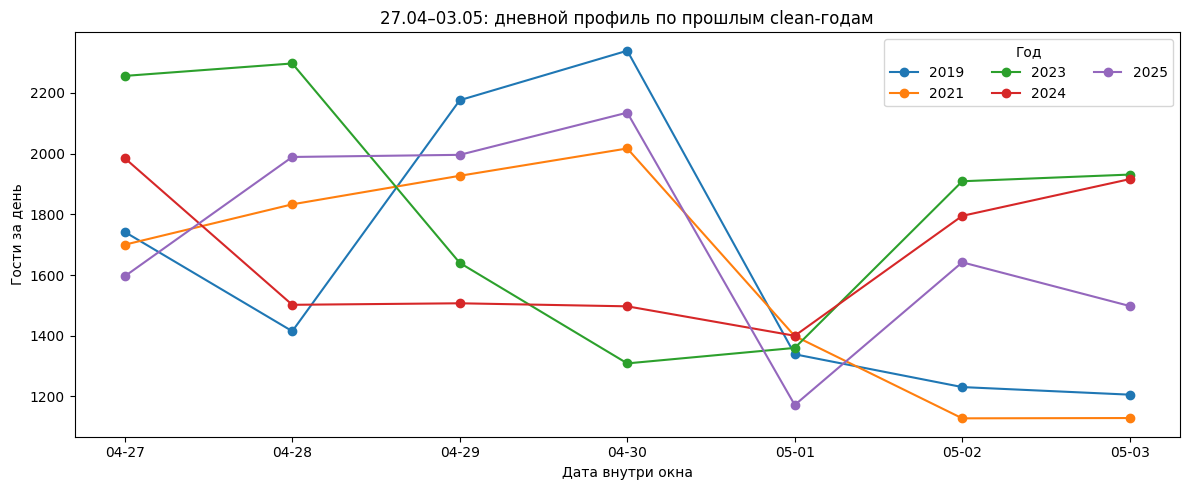

,month_day,median_daily_guests,mean_daily_guests,min_daily_guests,max_daily_guests,years_count
0,04-27,1742.0,1855.8,1596.0,2256.0,5
1,04-28,1833.0,1807.2,1415.0,2297.0,5
2,04-29,1927.0,1849.2,1507.0,2176.0,5
3,04-30,2017.0,1859.4,1309.0,2339.0,5
4,05-01,1360.0,1334.0,1172.0,1400.0,5
5,05-02,1642.0,1541.0,1128.0,1909.0,5
6,05-03,1498.0,1536.0,1129.0,1931.0,5


**Что показывает график.** Для окна 27.04–03.05 виден исторический профиль майских праздников: какие даты внутри окна обычно сильнее/слабее по гостям, и насколько этот профиль стабилен между clean-годами. Это лучший аргумент для сезонных known features (`month`, `day_of_month`, `day_of_week`, holiday flags), потому что модель должна заранее знать календарный контекст будущей недели.

In [13]:
# Daily profile for 27.04–03.05 in historical clean years.
window_daily = window_hist.groupby(["year", "sale_date"], as_index=False)["guests_count"].sum()
window_daily["month_day"] = window_daily["sale_date"].dt.strftime("%m-%d")

fig, ax = plt.subplots(figsize=(12, 5))
for year, part in window_daily.groupby("year"):
    ax.plot(part["month_day"], part["guests_count"], marker="o", linewidth=1.5, label=str(year))
ax.set_title("27.04–03.05: дневной профиль по прошлым clean-годам")
ax.set_xlabel("Дата внутри окна")
ax.set_ylabel("Гости за день")
ax.legend(title="Год", ncol=3)
plt.tight_layout()
plt.show()

summary_by_day = window_daily.groupby("month_day", as_index=False).agg(
    median_daily_guests=("guests_count", "median"),
    mean_daily_guests=("guests_count", "mean"),
    min_daily_guests=("guests_count", "min"),
    max_daily_guests=("guests_count", "max"),
    years_count=("year", "nunique"),
)
display(summary_by_day)

display(Markdown("""**Что показывает график.** Для окна 27.04–03.05 виден исторический профиль майских праздников: какие даты внутри окна обычно сильнее/слабее по гостям, и насколько этот профиль стабилен между clean-годами. Это лучший аргумент для сезонных known features (`month`, `day_of_month`, `day_of_week`, holiday flags), потому что модель должна заранее знать календарный контекст будущей недели."""))

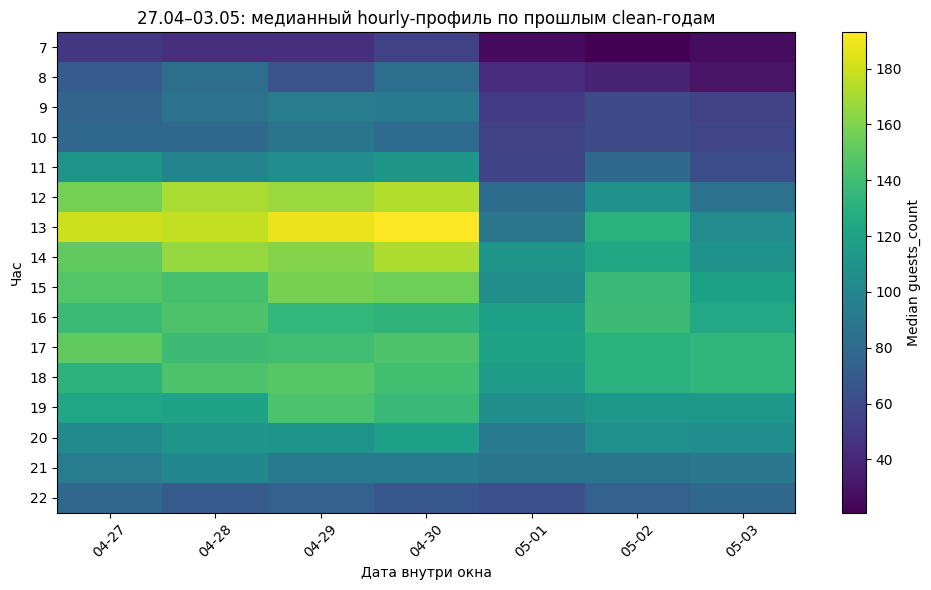

**Что показывает heatmap.** Внутри майского окна спрос неодинаков по часам: обычно есть дневные/вечерние пики и более слабые утренние часы. Для TFT это объясняет, зачем нужны `hour`, `hour_x_holiday`, `hour_x_preholiday`, `hour_x_official_day_off`: один и тот же праздник может по-разному влиять на разные часы дня.

In [14]:
# Hourly heatmap: median guests by date inside 27.04–03.05 and hour.
window_hist["month_day"] = window_hist["sale_date"].dt.strftime("%m-%d")
hourly_pivot = window_hist.pivot_table(
    index="hour", columns="month_day", values="guests_count", aggfunc="median"
).sort_index()

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(hourly_pivot.values, aspect="auto")
ax.set_title("27.04–03.05: медианный hourly-профиль по прошлым clean-годам")
ax.set_xlabel("Дата внутри окна")
ax.set_ylabel("Час")
ax.set_xticks(np.arange(len(hourly_pivot.columns)))
ax.set_xticklabels(hourly_pivot.columns, rotation=45)
ax.set_yticks(np.arange(len(hourly_pivot.index)))
ax.set_yticklabels(hourly_pivot.index)
fig.colorbar(im, ax=ax, label="Median guests_count")
plt.tight_layout()
plt.show()

display(Markdown("""**Что показывает heatmap.** Внутри майского окна спрос неодинаков по часам: обычно есть дневные/вечерние пики и более слабые утренние часы. Для TFT это объясняет, зачем нужны `hour`, `hour_x_holiday`, `hour_x_preholiday`, `hour_x_official_day_off`: один и тот же праздник может по-разному влиять на разные часы дня."""))

## 7. Общая сезонность временного ряда

Здесь показываем базовую сезонность: по часам, дням недели и комбинации weekday × hour. Эти графики напрямую связаны с признаками `hour`, `day_of_week`, `is_weekend` из training notebook.

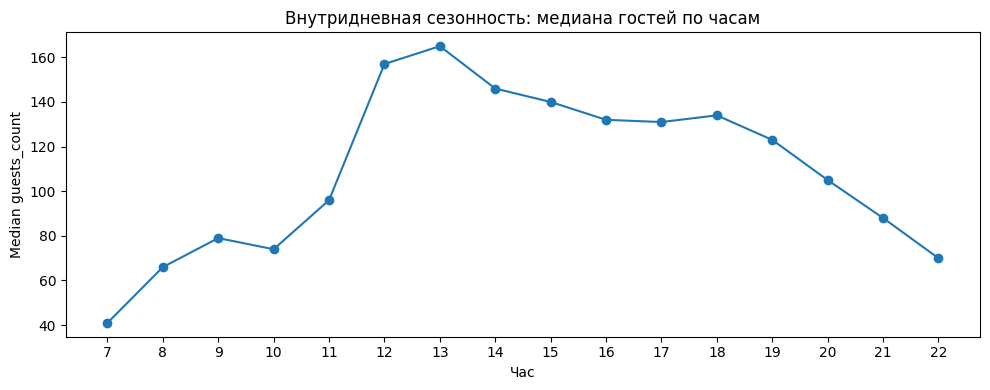

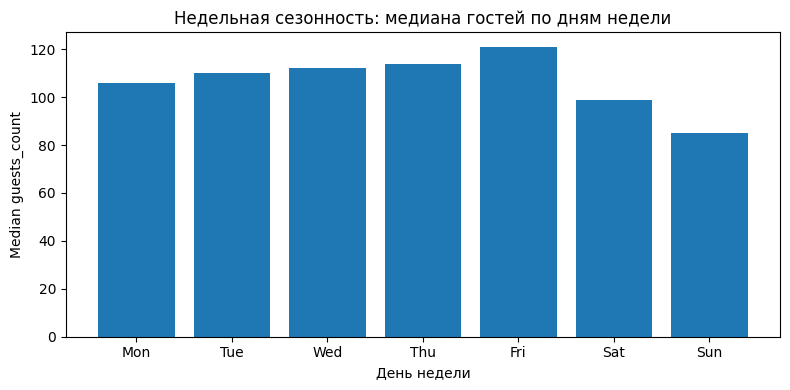

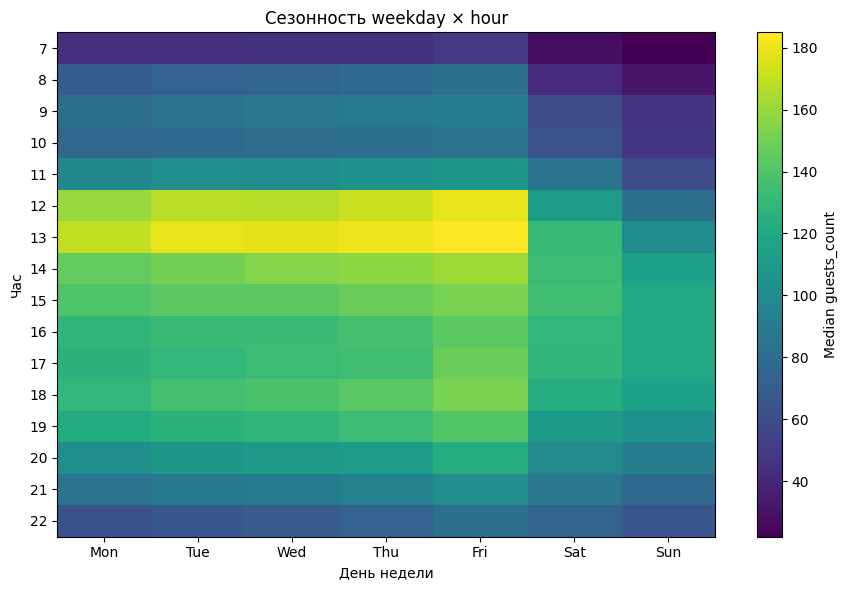

**Вывод для презентации.** У ряда есть выраженная внутридневная и недельная сезонность. Поэтому признаки `hour`, `day_of_week`, `is_weekend` не являются декоративными: они кодируют повторяющиеся паттерны спроса, которые transformer/TFT может использовать как known future inputs.

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
hour_profile = features_df.groupby("hour", as_index=False)["guests_count"].median()
ax.plot(hour_profile["hour"], hour_profile["guests_count"], marker="o")
ax.set_title("Внутридневная сезонность: медиана гостей по часам")
ax.set_xlabel("Час")
ax.set_ylabel("Median guests_count")
ax.set_xticks(hour_profile["hour"])
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
weekday_profile = features_df.groupby("day_of_week", as_index=False)["guests_count"].median()
weekday_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
ax.bar(weekday_profile["day_of_week"], weekday_profile["guests_count"])
ax.set_title("Недельная сезонность: медиана гостей по дням недели")
ax.set_xlabel("День недели")
ax.set_ylabel("Median guests_count")
ax.set_xticks(range(7))
ax.set_xticklabels(weekday_labels)
plt.tight_layout()
plt.show()

weekday_hour = features_df.pivot_table(index="hour", columns="day_of_week", values="guests_count", aggfunc="median")
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(weekday_hour.values, aspect="auto")
ax.set_title("Сезонность weekday × hour")
ax.set_xlabel("День недели")
ax.set_ylabel("Час")
ax.set_xticks(np.arange(7))
ax.set_xticklabels(weekday_labels)
ax.set_yticks(np.arange(len(weekday_hour.index)))
ax.set_yticklabels(weekday_hour.index)
fig.colorbar(im, ax=ax, label="Median guests_count")
plt.tight_layout()
plt.show()

display(Markdown("""**Вывод для презентации.** У ряда есть выраженная внутридневная и недельная сезонность. Поэтому признаки `hour`, `day_of_week`, `is_weekend` не являются декоративными: они кодируют повторяющиеся паттерны спроса, которые transformer/TFT может использовать как known future inputs."""))

## 8. Autocorrelation: память ряда

Проверяем, есть ли связь текущего спроса с прошлыми значениями на лагах. Для часового ряда с 16 рабочими часами в день особенно важны лаги 16, 112 и кратные им: вчера, неделя назад и т.д.

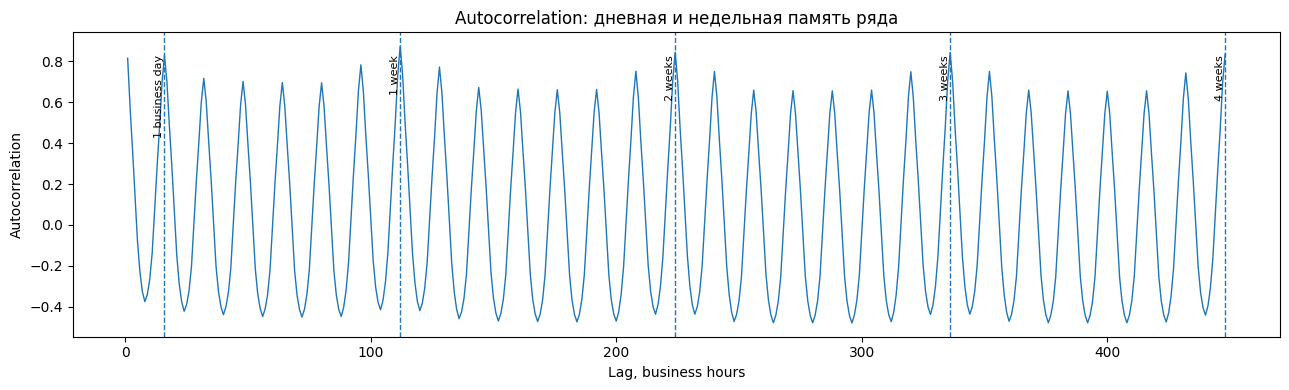

,lag_hours,autocorrelation,lag_days_business_hours
15,16,0.829093,1.0
111,112,0.874910,7.0
223,224,0.845471,14.0
335,336,0.843845,21.0
447,448,0.836493,28.0


**Вывод для презентации.** Пики корреляции на дневных/недельных лагах означают, что ряд имеет память. Это поддерживает выбор encoder window в TFT: модель смотрит назад на несколько недель и может сопоставлять текущий час/день с похожими историческими ситуациями.

In [16]:
ts = features_df.sort_values(["segment_id", "timestamp"])[["segment_id", "timestamp", "guests_count"]].copy()
# For a simple presentation ACF, use the longest segment to avoid artificial jumps across large gaps.
longest_segment = ts.groupby("segment_id").size().idxmax()
ts_long = ts[ts["segment_id"].eq(longest_segment)].copy().reset_index(drop=True)
y = ts_long["guests_count"].astype(float)

lags = list(range(1, 16 * 28 + 1))
acf = []
for lag in lags:
    acf.append(y.autocorr(lag=lag))
acf_df = pd.DataFrame({"lag_hours": lags, "autocorrelation": acf})
acf_df["lag_days_business_hours"] = acf_df["lag_hours"] / 16

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(acf_df["lag_hours"], acf_df["autocorrelation"], linewidth=1)
for lag, label in [(16, "1 business day"), (16*7, "1 week"), (16*14, "2 weeks"), (16*21, "3 weeks"), (16*28, "4 weeks")]:
    ax.axvline(lag, linestyle="--", linewidth=1)
    ax.text(lag, np.nanmax(acf_df["autocorrelation"]) * 0.95, label, rotation=90, va="top", ha="right", fontsize=8)
ax.set_title("Autocorrelation: дневная и недельная память ряда")
ax.set_xlabel("Lag, business hours")
ax.set_ylabel("Autocorrelation")
plt.tight_layout()
plt.show()

display(acf_df.loc[acf_df["lag_hours"].isin([16, 112, 224, 336, 448])])

display(Markdown("""**Вывод для презентации.** Пики корреляции на дневных/недельных лагах означают, что ряд имеет память. Это поддерживает выбор encoder window в TFT: модель смотрит назад на несколько недель и может сопоставлять текущий час/день с похожими историческими ситуациями."""))

## 9. Корреляционная матрица признаков

Heatmap строится только по признакам из training notebook, которые реально есть в этом EDA-датафрейме. Категориальные признаки для EDA кодируются численно **только для визуализации корреляций**; в TFT они остаются категориальными.

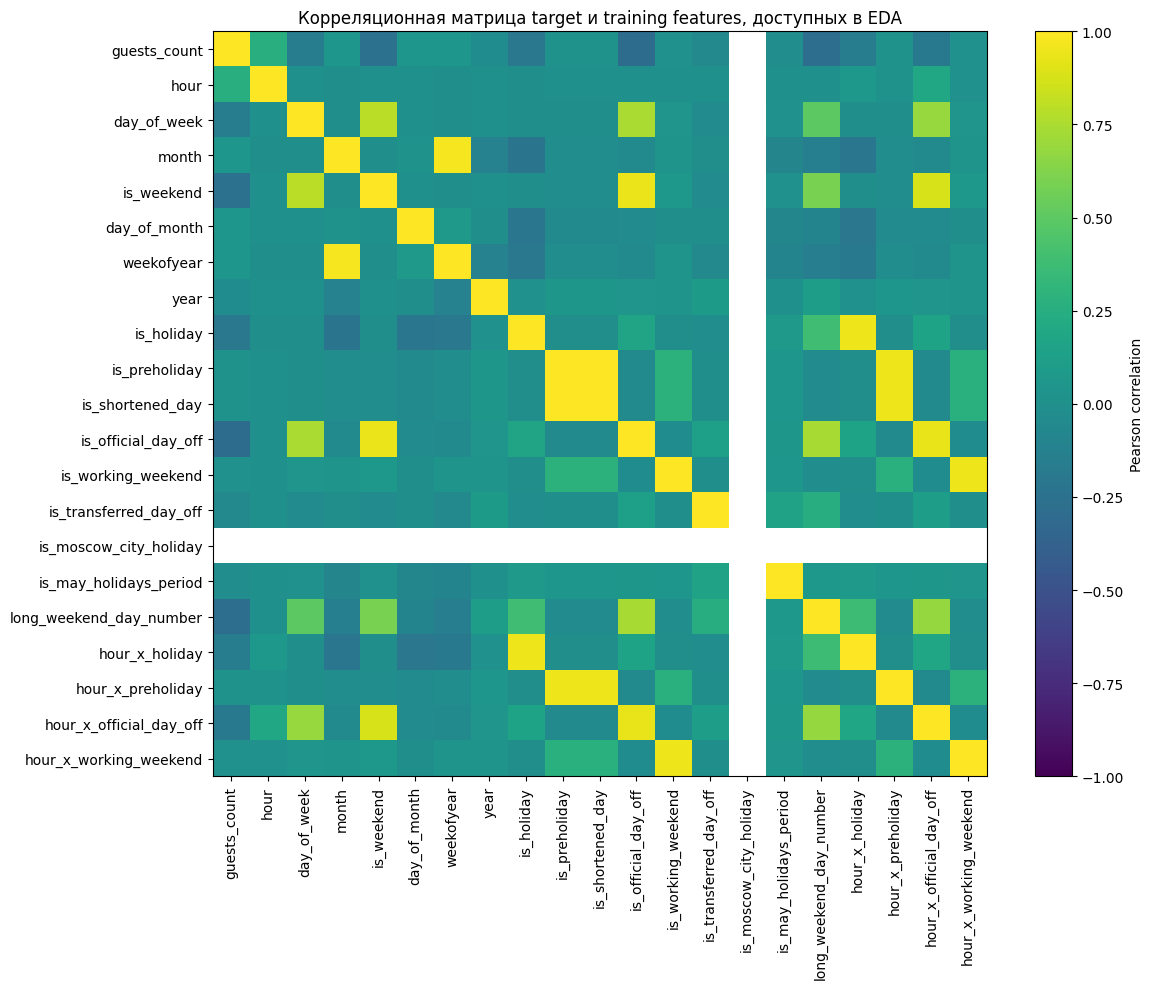

,corr_with_guests_count
is_official_day_off,-0.295367
long_weekend_day_number,-0.279697
hour,0.257441
is_weekend,-0.256632
is_holiday,-0.198014
hour_x_official_day_off,-0.193093
hour_x_holiday,-0.161871
day_of_week,-0.160332
is_transferred_day_off,-0.058453
day_of_month,0.054481


**Что показывает heatmap.** Корреляционная матрица помогает проверить, какие календарные/holiday-признаки связаны с таргетом и нет ли очевидных дубликатов. Для модели это не жесткий фильтр признаков, но хороший sanity check перед обучением: признаки должны быть интерпретируемыми, доступными в будущем и не содержать target leakage.

In [17]:
corr_base_cols = [
    "guests_count",
    "hour", "day_of_week", "month", "is_weekend",
    "day_of_month", "weekofyear", "year",
    "is_holiday", "is_preholiday", "is_shortened_day", "is_official_day_off",
    "is_working_weekend", "is_transferred_day_off", "is_moscow_city_holiday", "is_may_holidays_period",
    "long_weekend_day_number", "hour_x_holiday", "hour_x_preholiday",
    "hour_x_official_day_off", "hour_x_working_weekend",
]

corr_cols = [c for c in corr_base_cols if c in features_df.columns]
corr_df = features_df[corr_cols].copy()
for col in corr_df.columns:
    if not pd.api.types.is_numeric_dtype(corr_df[col]):
        corr_df[col] = pd.factorize(corr_df[col].astype(str))[0]

corr = corr_df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr.values, vmin=-1, vmax=1, aspect="auto")
ax.set_title("Корреляционная матрица target и training features, доступных в EDA")
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.index)
fig.colorbar(im, ax=ax, label="Pearson correlation")
plt.tight_layout()
plt.show()

target_corr = corr["guests_count"].drop("guests_count").sort_values(key=lambda s: s.abs(), ascending=False).to_frame("corr_with_guests_count")
display(target_corr.head(15))

display(Markdown("""**Что показывает heatmap.** Корреляционная матрица помогает проверить, какие календарные/holiday-признаки связаны с таргетом и нет ли очевидных дубликатов. Для модели это не жесткий фильтр признаков, но хороший sanity check перед обучением: признаки должны быть интерпретируемыми, доступными в будущем и не содержать target leakage."""))

## 10. Итоговая готовность данных к обучению transformer/TFT

Финальный блок формулирует главные аргументы для защиты решения.

In [18]:
readiness = pd.DataFrame({
    "check": [
        "Hourly target is aggregated to unique timestamps",
        "Business hours match training config",
        "Large gaps are separated by segment_id",
        "Abnormal periods are excluded",
        "27.04–03.05 is analyzed on past clean years",
        "No invented month_sin/month_cos features",
        "EDA features align with training notebook",
        "Known future features are calendar/holiday/weather, not target-derived",
    ],
    "status": [
        "OK" if df["timestamp"].duplicated().sum() == 0 else "CHECK",
        "OK" if (df["sale_hour"].min() == BUSINESS_START_HOUR and df["sale_hour"].max() == BUSINESS_END_HOUR) else "CHECK",
        "OK" if features_df["segment_id"].nunique() >= 1 else "CHECK",
        "OK" if len(aligned) > len(clean_df) else "CHECK",
        "OK" if len(window_hist) > 0 and window_hist["year"].max() < max_year else "CHECK",
        "OK" if not any(c in features_df.columns for c in ["month_sin", "month_cos"]) else "CHECK",
        "OK" if set(available_feature_cols).issubset(set(TIME_VARYING_KNOWN_CATEGORICALS + TIME_VARYING_KNOWN_REALS)) else "CHECK",
        "OK",
    ],
    "presentation_comment": [
        "После groupby(timestamp) одна строка соответствует одному часу.",
        "Используем 07:00–22:00, как в TFTPipelineConfig.",
        "Разрывы >14 дней не превращаются в искусственную непрерывную историю.",
        "COVID/rebrand/QR-периоды удалены из clean train distribution.",
        "Будущее окно объясняем через историческую сезонность прошлых clean-лет.",
        "Циклические month-фичи не добавлялись, потому что их нет в обучении.",
        "Список признаков взят из training notebook: baseline + holiday + weather.",
        "Known future inputs можно знать до прогноза; target не используется как future feature.",
    ]
})
display(readiness)

# Save artifacts for reuse.
clean_out = Path("/content/clean_guests_for_hackathon_corrected.csv")
features_out = Path("/content/features_for_transformer_hackathon_corrected.csv")
clean_df.to_csv(clean_out, index=False)
features_df.to_csv(features_out, index=False)
print("Saved:", clean_out)
print("Saved:", features_out)

,check,status,presentation_comment
0,Hourly target is aggregated to unique timestamps,OK,После groupby(timestamp) одна строка соответст...
1,Business hours match training config,OK,"Используем 07:00–22:00, как в TFTPipelineConfig."
2,Large gaps are separated by segment_id,OK,Разрывы >14 дней не превращаются в искусственн...
3,Abnormal periods are excluded,OK,COVID/rebrand/QR-периоды удалены из clean trai...
4,27.04–03.05 is analyzed on past clean years,OK,Будущее окно объясняем через историческую сезо...
5,No invented month_sin/month_cos features,OK,"Циклические month-фичи не добавлялись, потому ..."
6,EDA features align with training notebook,OK,Список признаков взят из training notebook: ba...
7,Known future features are calendar/holiday/wea...,OK,Known future inputs можно знать до прогноза; t...


Saved: /content/clean_guests_for_hackathon_corrected.csv
Saved: /content/features_for_transformer_hackathon_corrected.csv


## Анализ зависимости `guests_count` от weather/calendar features из training notebook

В этом блоке мы анализируем **ровно те группы признаков**, которые используются в `01_train_weather_tft_prod_calendar_8weeks.ipynb`:

- baseline calendar categoricals: `hour`, `day_of_week`, `month`, `is_weekend`;
- baseline calendar reals: `day_of_month`, `weekofyear`, `year`;
- holiday features;
- weather features: фактическая историческая погода + производные признаки.

Важно: для корреляций категориальные признаки временно кодируются числами **только для EDA-графиков**. В TFT они остаются категориальными.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

TARGET_COL = "guests_count"
DATETIME_COL = "timestamp"

# Ровно из training notebook
BASELINE_KNOWN_CATEGORICALS = [
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
]

BASELINE_KNOWN_REALS = [
    "day_of_month",
    "weekofyear",
    "year",
]

HOLIDAY_KNOWN_CATEGORICALS = [
    "is_holiday",
    "is_preholiday",
    "is_shortened_day",
    "is_official_day_off",
    "is_working_weekend",
    "is_transferred_day_off",
    "is_moscow_city_holiday",
    "is_may_holidays_period",
    "production_day_type",
    "holiday_name",
]

HOLIDAY_KNOWN_REALS = [
    "long_weekend_day_number",
    "hour_x_holiday",
    "hour_x_preholiday",
    "hour_x_official_day_off",
    "hour_x_working_weekend",
]

WEATHER_KNOWN_CATEGORICALS = [
    "weather_code",
    "is_day",
    "has_precipitation",
    "has_rain",
    "has_snowfall",
    "is_cloudy",
    "is_windy",
    "precipitation_level",
    "temperature_bin",
]

WEATHER_KNOWN_REALS = [
    "temperature_2m",
    "apparent_temperature",
    "precipitation",
    "rain",
    "snowfall",
    "relative_humidity_2m",
    "cloud_cover",
    "wind_speed_10m",
    "wind_gusts_10m",
    "hour_x_precipitation",
    "hour_x_temperature",
]

WEATHER_COLS = [
    "temperature_2m",
    "apparent_temperature",
    "precipitation",
    "rain",
    "snowfall",
    "relative_humidity_2m",
    "cloud_cover",
    "wind_speed_10m",
    "wind_gusts_10m",
    "weather_code",
    "is_day",
]

DEFAULT_WEATHER_VALUES = {
    "temperature_2m": 10.0,
    "apparent_temperature": 10.0,
    "precipitation": 0.0,
    "rain": 0.0,
    "snowfall": 0.0,
    "relative_humidity_2m": 60.0,
    "cloud_cover": 50.0,
    "wind_speed_10m": 3.0,
    "wind_gusts_10m": 6.0,
    "weather_code": 0.0,
    "is_day": 1.0,
}

TRAINING_FEATURES = (
    BASELINE_KNOWN_CATEGORICALS
    + BASELINE_KNOWN_REALS
    + HOLIDAY_KNOWN_CATEGORICALS
    + HOLIDAY_KNOWN_REALS
    + WEATHER_KNOWN_CATEGORICALS
    + WEATHER_KNOWN_REALS
)

print("Всего feature columns из training notebook:", len(TRAINING_FEATURES))
print(TRAINING_FEATURES)

Всего feature columns из training notebook: 42
['hour', 'day_of_week', 'month', 'is_weekend', 'day_of_month', 'weekofyear', 'year', 'is_holiday', 'is_preholiday', 'is_shortened_day', 'is_official_day_off', 'is_working_weekend', 'is_transferred_day_off', 'is_moscow_city_holiday', 'is_may_holidays_period', 'production_day_type', 'holiday_name', 'long_weekend_day_number', 'hour_x_holiday', 'hour_x_preholiday', 'hour_x_official_day_off', 'hour_x_working_weekend', 'weather_code', 'is_day', 'has_precipitation', 'has_rain', 'has_snowfall', 'is_cloudy', 'is_windy', 'precipitation_level', 'temperature_bin', 'temperature_2m', 'apparent_temperature', 'precipitation', 'rain', 'snowfall', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'wind_gusts_10m', 'hour_x_precipitation', 'hour_x_temperature']


In [20]:
def add_weather_derived_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Производные weather features ровно как в training notebook.
    """
    df = df.copy()

    for col, default_value in DEFAULT_WEATHER_VALUES.items():
        if col not in df.columns:
            df[col] = default_value
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(default_value)

    df["has_precipitation"] = (df["precipitation"] > 0).astype(int)
    df["has_rain"] = (df["rain"] > 0).astype(int)
    df["has_snowfall"] = (df["snowfall"] > 0).astype(int)
    df["is_cloudy"] = (df["cloud_cover"] >= 70).astype(int)
    df["is_windy"] = (df["wind_speed_10m"] >= 8).astype(int)

    df["precipitation_level"] = pd.cut(
        df["precipitation"],
        bins=[-0.01, 0, 1, 3, np.inf],
        labels=["none", "light", "medium", "heavy"],
    ).astype(str)

    df["temperature_bin"] = pd.cut(
        df["temperature_2m"],
        bins=[-50, 0, 10, 18, 25, 50],
        labels=["freezing", "cold", "cool", "warm", "hot"],
    ).astype(str)

    df["hour_x_precipitation"] = df["hour"] * df["has_precipitation"]
    df["hour_x_temperature"] = df["hour"] * df["temperature_2m"]

    return df


def download_open_meteo_weather(min_date, max_date, latitude=55.8018477029042, longitude=37.53210649745259):
    """
    Скачивает фактическую историческую погоду так же по смыслу, как training notebook.
    Работает в окружении с интернетом.
    """
    import requests

    min_date = pd.Timestamp(min_date).strftime("%Y-%m-%d")
    max_date = pd.Timestamp(max_date).strftime("%Y-%m-%d")

    response = requests.get(
        "https://archive-api.open-meteo.com/v1/archive",
        params={
            "latitude": latitude,
            "longitude": longitude,
            "start_date": min_date,
            "end_date": max_date,
            "hourly": WEATHER_COLS,
            "timezone": "Europe/Moscow",
        },
        timeout=60,
    )
    response.raise_for_status()

    weather_json = response.json()
    weather = pd.DataFrame(weather_json["hourly"])
    weather["timestamp"] = pd.to_datetime(weather["time"])
    weather = weather.drop(columns=["time"])
    return weather


def prepare_weather_feature_frame():
    """
    Приоритет:
    1. если уже есть train_df из training notebook - берем его, там уже есть weather;
    2. если есть локальный файл с weather features - берем его;
    3. если есть clean/features файл без weather - скачиваем weather и мержим.
    """
    if "train_df" in globals():
        df = train_df.copy()
        print("Использую train_df из training notebook.")
    elif Path("features_for_transformer_hackathon_corrected.csv").exists():
        df = pd.read_csv("features_for_transformer_hackathon_corrected.csv")
        print("Использую features_for_transformer_hackathon_corrected.csv.")
    elif Path("clean_guests_for_hackathon_corrected.csv").exists():
        df = pd.read_csv("clean_guests_for_hackathon_corrected.csv")
        print("Использую clean_guests_for_hackathon_corrected.csv.")
    elif Path("clean_guests.csv").exists():
        df = pd.read_csv("clean_guests.csv")
        print("Использую clean_guests.csv.")
    else:
        raise FileNotFoundError("Не нашел train_df / features csv / clean csv.")

    df[DATETIME_COL] = pd.to_datetime(df[DATETIME_COL])
    if "sale_date" not in df.columns:
        df["sale_date"] = df[DATETIME_COL].dt.normalize()
    else:
        df["sale_date"] = pd.to_datetime(df["sale_date"]).dt.normalize()

    if "hour" not in df.columns:
        if "sale_hour" in df.columns:
            df["hour"] = df["sale_hour"]
        else:
            df["hour"] = df[DATETIME_COL].dt.hour

    # Если есть отметка normal/cut, берем только нормальные наблюдения для EDA.
    if "period_type" in df.columns:
        before = len(df)
        df = df[df["period_type"].eq("normal")].copy()
        print(f"Оставили только period_type == normal: {len(df):,} из {before:,} строк.")

    # Если погодных колонок еще нет, скачиваем фактическую погоду и добавляем derived features.
    missing_base_weather = [c for c in WEATHER_COLS if c not in df.columns]
    if missing_base_weather:
        print("В текущем df нет weather columns, скачиваю Open-Meteo:", missing_base_weather)
        weather = download_open_meteo_weather(df["sale_date"].min(), df["sale_date"].max())
        df = df.merge(weather, on="timestamp", how="left")

    df = add_weather_derived_features(df)

    # Контроль наличия ровно тех weather features, которые использует training notebook.
    missing_weather_features = [c for c in WEATHER_KNOWN_CATEGORICALS + WEATHER_KNOWN_REALS if c not in df.columns]
    if missing_weather_features:
        raise ValueError(f"Не хватает weather features: {missing_weather_features}")

    print("Rows:", len(df))
    print("Date range:", df[DATETIME_COL].min(), "—", df[DATETIME_COL].max())
    return df


weather_df = prepare_weather_feature_frame()
display(weather_df[[DATETIME_COL, TARGET_COL] + WEATHER_COLS].head())

Использую features_for_transformer_hackathon_corrected.csv.
Оставили только period_type == normal: 15,344 из 36,688 строк.
В текущем df нет weather columns, скачиваю Open-Meteo: ['temperature_2m', 'apparent_temperature', 'precipitation', 'rain', 'snowfall', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'wind_gusts_10m', 'weather_code', 'is_day']
Rows: 15344
Date range: 2019-01-02 07:00:00 — 2022-03-07 22:00:00


,timestamp,guests_count,temperature_2m,apparent_temperature,precipitation,rain,snowfall,relative_humidity_2m,cloud_cover,wind_speed_10m,wind_gusts_10m,weather_code,is_day
0,2019-01-02 07:00:00,5.0,-3.5,-10.6,0.1,0.0,0.07,87,100,29.5,43.2,71,0
1,2019-01-02 08:00:00,11.0,-3.7,-10.8,0.1,0.0,0.07,87,100,29.2,41.4,71,0
2,2019-01-02 09:00:00,14.0,-3.7,-10.8,0.1,0.0,0.07,87,100,29.0,41.0,71,1
3,2019-01-02 10:00:00,17.0,-3.5,-10.6,0.2,0.0,0.14,87,100,29.3,40.3,71,1
4,2019-01-02 11:00:00,28.0,-3.2,-10.4,0.1,0.0,0.07,87,100,29.9,41.4,71,1


### 1. Быстрая проверка: какие weather features реально есть

Сначала проверяем, что в датафрейме появились погодные признаки из training pipeline. Это важно, чтобы не анализировать случайные или придуманные фичи.

In [21]:
feature_presence = pd.DataFrame({
    "feature": TRAINING_FEATURES,
    "present_in_df": [f in weather_df.columns for f in TRAINING_FEATURES],
    "feature_group": (
        ["baseline_categorical"] * len(BASELINE_KNOWN_CATEGORICALS)
        + ["baseline_real"] * len(BASELINE_KNOWN_REALS)
        + ["holiday_categorical"] * len(HOLIDAY_KNOWN_CATEGORICALS)
        + ["holiday_real"] * len(HOLIDAY_KNOWN_REALS)
        + ["weather_categorical"] * len(WEATHER_KNOWN_CATEGORICALS)
        + ["weather_real"] * len(WEATHER_KNOWN_REALS)
    )
})

display(feature_presence)
print("Missing:", feature_presence.loc[~feature_presence["present_in_df"], "feature"].tolist())

,feature,present_in_df,feature_group
0,hour,True,baseline_categorical
1,day_of_week,True,baseline_categorical
2,month,True,baseline_categorical
3,is_weekend,True,baseline_categorical
4,day_of_month,True,baseline_real
5,weekofyear,True,baseline_real
6,year,True,baseline_real
7,is_holiday,True,holiday_categorical
8,is_preholiday,True,holiday_categorical
9,is_shortened_day,True,holiday_categorical


Missing: []


### 2. Корреляция таргета с numeric weather features

Здесь смотрим линейную связь `guests_count` с числовыми погодными признаками. Это не доказывает причинность, но показывает, какие погодные переменные потенциально несут сигнал для модели.

,feature,corr_with_guests_count
0,relative_humidity_2m,-0.373855
1,hour_x_temperature,0.262629
2,temperature_2m,0.259846
3,apparent_temperature,0.237886
4,wind_gusts_10m,0.158769
5,snowfall,-0.079201
6,wind_speed_10m,0.042005
7,cloud_cover,-0.032531
8,rain,0.022007
9,precipitation,-0.013852


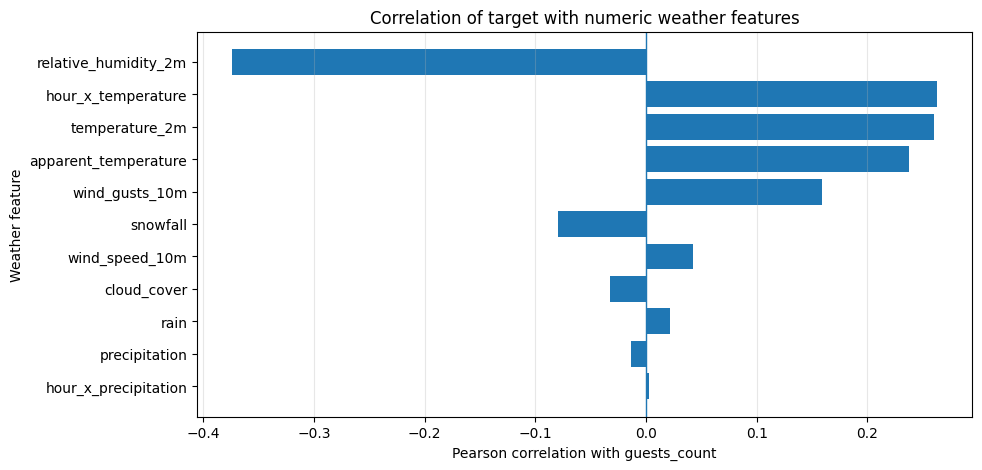

In [22]:
weather_numeric = [c for c in WEATHER_KNOWN_REALS if c in weather_df.columns]
corr_target_weather = (
    weather_df[[TARGET_COL] + weather_numeric]
    .corr(numeric_only=True)[TARGET_COL]
    .drop(TARGET_COL)
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .reset_index()
)
corr_target_weather.columns = ["feature", "corr_with_guests_count"]

display(corr_target_weather)

plt.figure(figsize=(10, 5))
plt.barh(corr_target_weather["feature"], corr_target_weather["corr_with_guests_count"])
plt.axvline(0, linewidth=1)
plt.title("Correlation of target with numeric weather features")
plt.xlabel("Pearson correlation with guests_count")
plt.ylabel("Weather feature")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.show()

### 3. Важный контроль: зависимость от погоды после удаления базовой календарной сезонности

Погода может быть смешана с календарем: например, температура выше летом, а спрос летом может отличаться сам по себе. Поэтому полезно смотреть не только `guests_count`, а **остаток после типичного календарного профиля**.

Мы строим baseline как медиану по `month × day_of_week × hour`, затем анализируем:

`target_residual = guests_count - median_guests_for_same_month_dayofweek_hour`

Если weather features коррелируют с этим остатком, значит они объясняют не только календарную сезонность, но и дополнительное отклонение спроса.

,feature,corr_with_residual_after_calendar
0,temperature_2m,0.109135
1,hour_x_temperature,0.105414
2,apparent_temperature,0.098812
3,relative_humidity_2m,-0.095094
4,hour_x_precipitation,-0.081453
5,precipitation,-0.075371
6,rain,-0.057360
7,snowfall,-0.054018
8,wind_gusts_10m,0.042371
9,cloud_cover,-0.031221


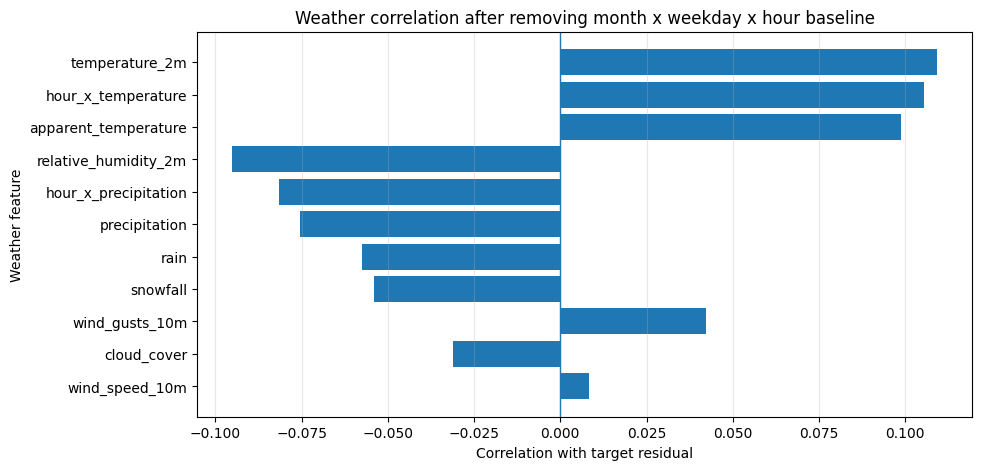

In [23]:
calendar_group = ["month", "day_of_week", "hour"]
for c in calendar_group:
    if c not in weather_df.columns:
        raise ValueError(f"Нет calendar column: {c}")

weather_df = weather_df.copy()
weather_df["calendar_baseline"] = (
    weather_df
    .groupby(calendar_group)[TARGET_COL]
    .transform("median")
)
weather_df["target_residual_after_calendar"] = weather_df[TARGET_COL] - weather_df["calendar_baseline"]
weather_df["target_ratio_to_calendar"] = weather_df[TARGET_COL] / weather_df["calendar_baseline"].replace(0, np.nan)

residual_corr = (
    weather_df[["target_residual_after_calendar"] + weather_numeric]
    .corr(numeric_only=True)["target_residual_after_calendar"]
    .drop("target_residual_after_calendar")
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .reset_index()
)
residual_corr.columns = ["feature", "corr_with_residual_after_calendar"]

display(residual_corr)

plt.figure(figsize=(10, 5))
plt.barh(residual_corr["feature"], residual_corr["corr_with_residual_after_calendar"])
plt.axvline(0, linewidth=1)
plt.title("Weather correlation after removing month x weekday x hour baseline")
plt.xlabel("Correlation with target residual")
plt.ylabel("Weather feature")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.show()

### 4. Средний таргет по погодным категориям

Эти графики проще всего объяснять на презентации:

- как меняется среднее число гостей при разных температурных бинах;
- как меняется спрос при разном уровне осадков;
- отличается ли спрос в дождь/снег/облачность/ветер.

Для честности рядом показываем `target_residual_after_calendar`: это эффект после учета типичного календарного профиля.

,temperature_bin,mean_value,median_value,rows
3,hot,137.979215,131.0,433
4,warm,126.826667,123.0,2025
0,cold,111.575243,107.0,4831
1,cool,110.915993,105.0,2845
2,freezing,91.955662,89.0,5210


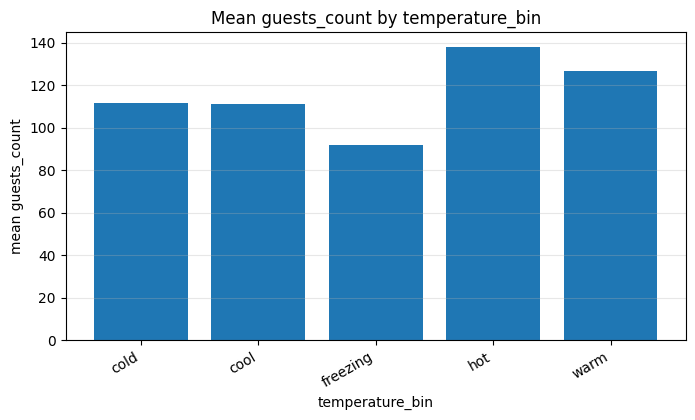

,temperature_bin,mean_value,median_value,rows
3,hot,4.027714,0.0,433
0,cold,3.980749,1.0,4831
4,warm,3.251852,0.0,2025
1,cool,1.321617,0.0,2845
2,freezing,-3.533973,-1.5,5210


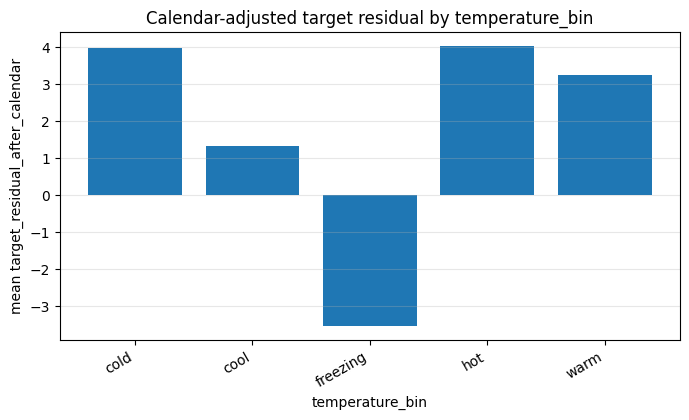

,precipitation_level,mean_value,median_value,rows
2,medium,109.033149,106.0,181
3,none,108.216953,103.0,12104
1,light,104.818748,102.0,3051


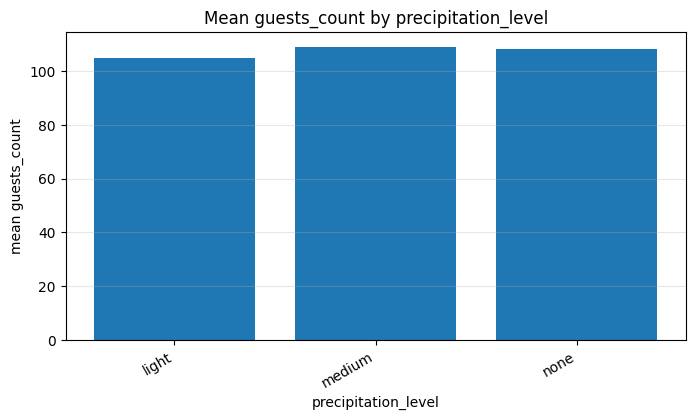

,precipitation_level,mean_value,median_value,rows
3,none,1.901355,0.0,12104
1,light,-2.876926,-1.5,3051
2,medium,-6.284530,-5.0,181


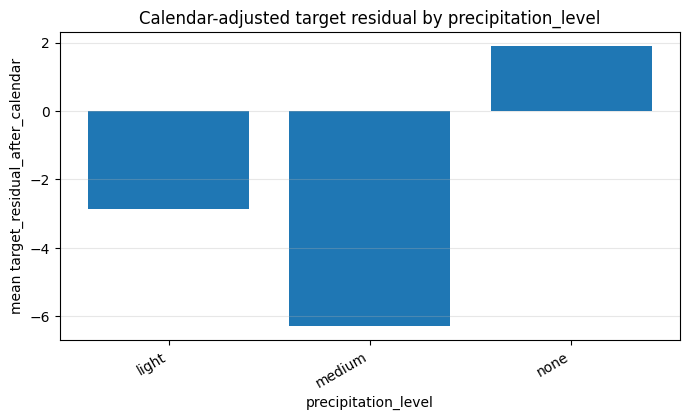

,has_precipitation,mean_value,median_value,rows
0,0,108.216953,103.0,12104
1,1,105.054321,102.0,3240


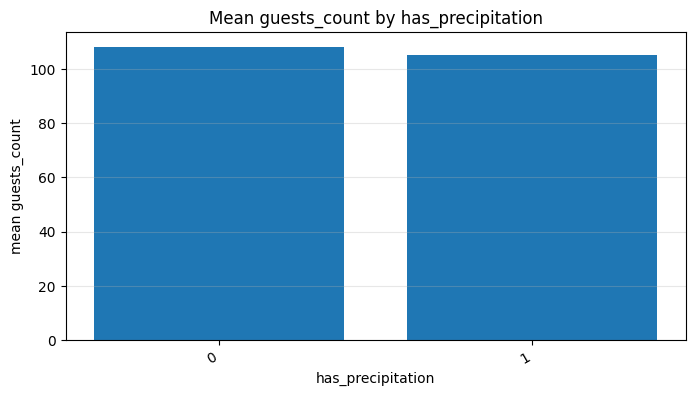

,has_precipitation,mean_value,median_value,rows
0,0,1.901355,0.0,12104
1,1,-3.119136,-1.5,3240


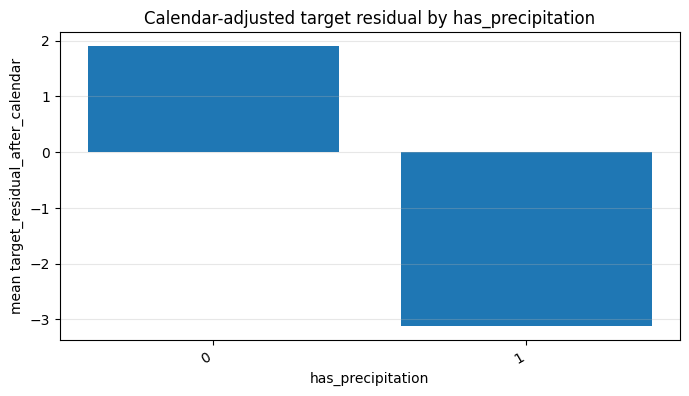

,has_rain,mean_value,median_value,rows
1,1,114.438249,111.0,1919
0,0,106.564395,102.0,13425


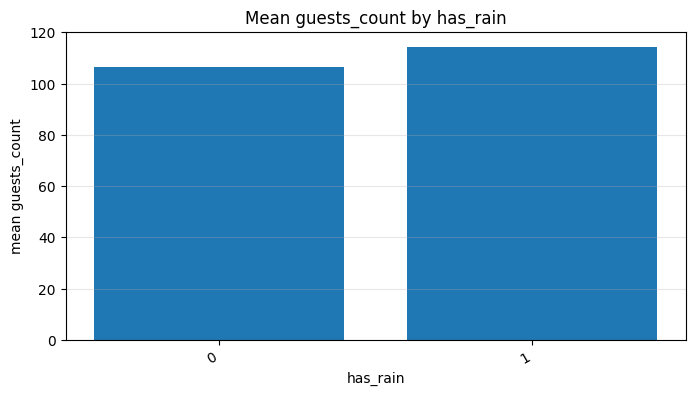

,has_rain,mean_value,median_value,rows
0,0,1.247449,0.0,13425
1,1,-2.000521,-1.0,1919


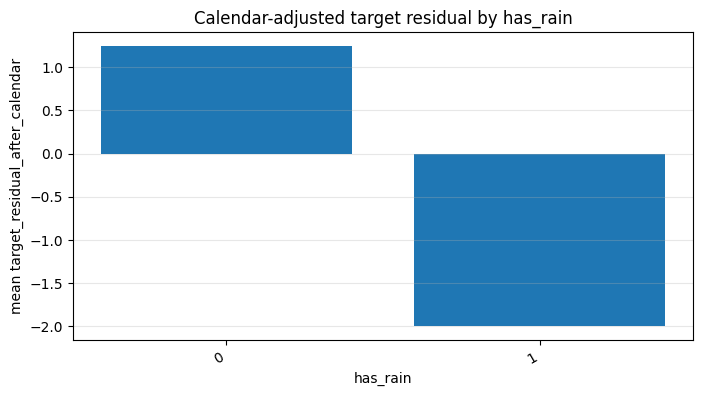

,has_snowfall,mean_value,median_value,rows
0,0,109.131625,104.0,13850
1,1,92.878849,91.0,1494


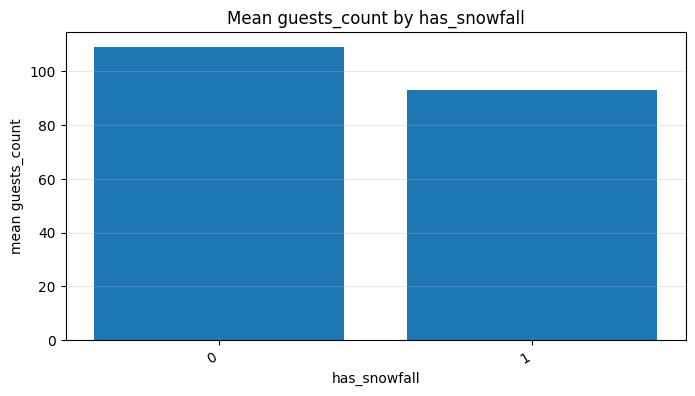

,has_snowfall,mean_value,median_value,rows
0,0,1.393394,0.0,13850
1,1,-4.277443,-2.5,1494


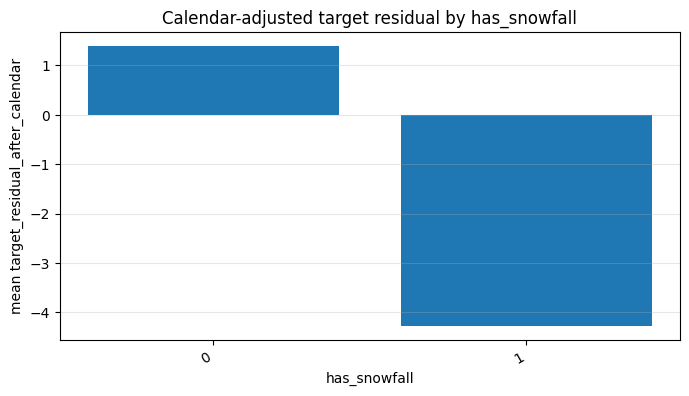

,is_cloudy,mean_value,median_value,rows
0,0,110.631626,106.0,4471
1,1,106.281615,102.0,10873


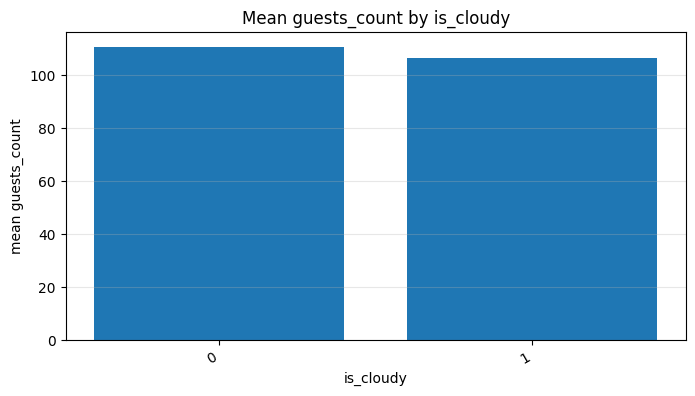

,is_cloudy,mean_value,median_value,rows
0,0,1.876202,0.0,4471
1,1,0.415663,0.0,10873


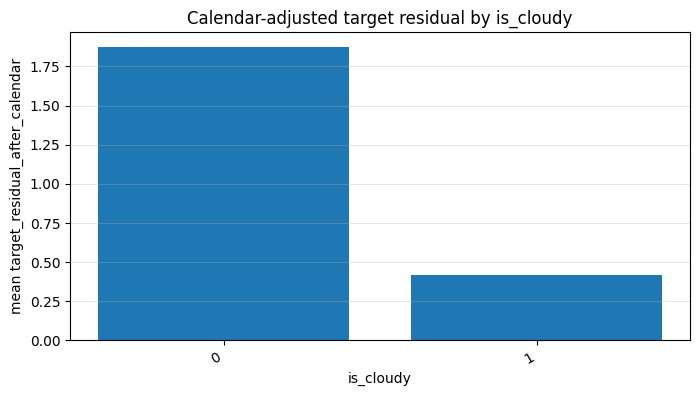

,is_windy,mean_value,median_value,rows
1,1,107.996919,104.0,13309
0,0,104.620639,99.0,2035


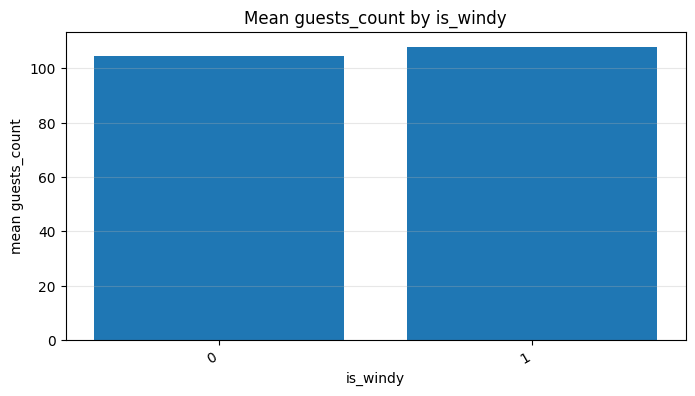

,is_windy,mean_value,median_value,rows
0,0,0.930958,0.0,2035
1,1,0.827523,0.0,13309


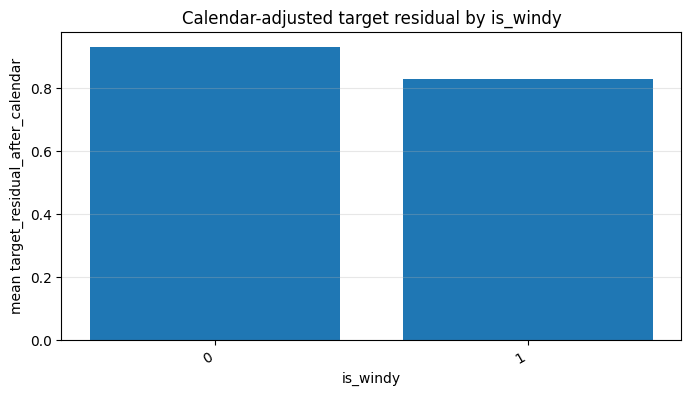

,is_day,mean_value,median_value,rows
1,1,117.545716,115.0,10445
0,0,86.235762,85.0,4899


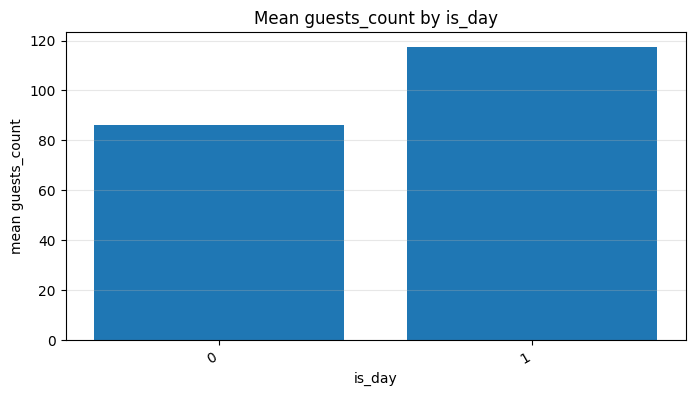

,is_day,mean_value,median_value,rows
1,1,1.105457,0.0,10445
0,0,0.277914,0.0,4899


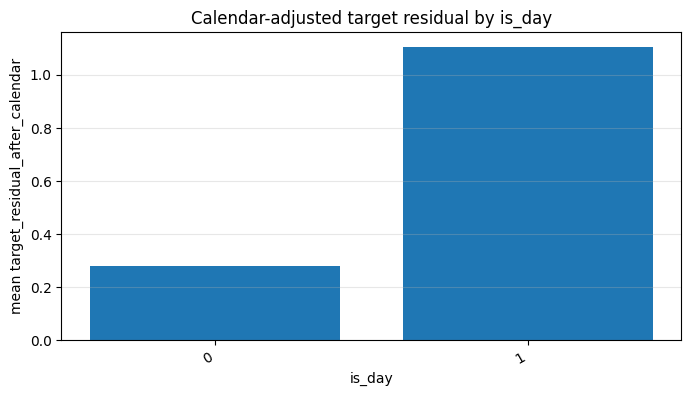

In [24]:
def plot_category_effect(df, category_col, metric_col, title, min_count=50):
    stats = (
        df.groupby(category_col, dropna=False)
        .agg(
            mean_value=(metric_col, "mean"),
            median_value=(metric_col, "median"),
            rows=(metric_col, "size"),
        )
        .reset_index()
    )
    stats = stats[stats["rows"] >= min_count].copy()

    display(stats.sort_values("mean_value", ascending=False))

    plt.figure(figsize=(8, 4))
    plt.bar(stats[category_col].astype(str), stats["mean_value"])
    plt.title(title)
    plt.xlabel(category_col)
    plt.ylabel(f"mean {metric_col}")
    plt.xticks(rotation=30, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

for cat in ["temperature_bin", "precipitation_level", "has_precipitation", "has_rain", "has_snowfall", "is_cloudy", "is_windy", "is_day"]:
    if cat in weather_df.columns:
        plot_category_effect(
            weather_df,
            category_col=cat,
            metric_col=TARGET_COL,
            title=f"Mean guests_count by {cat}",
        )
        plot_category_effect(
            weather_df,
            category_col=cat,
            metric_col="target_residual_after_calendar",
            title=f"Calendar-adjusted target residual by {cat}",
        )

### 5. Heatmap: target по `hour × temperature_bin` и `hour × precipitation_level`

Этот блок показывает, влияет ли погода по-разному в разные часы. Например, дождь может сильнее менять спрос вечером, чем утром.

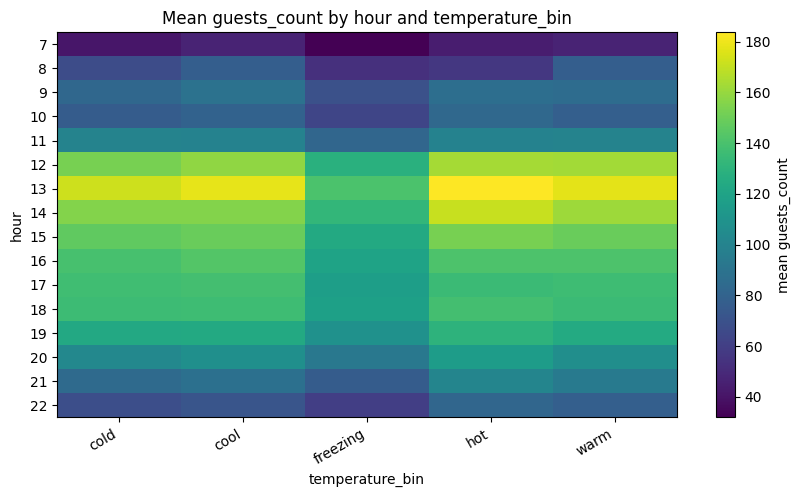

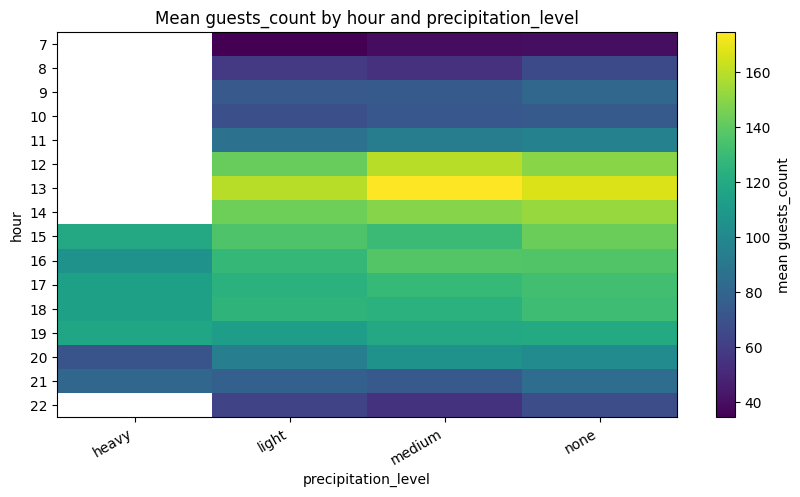

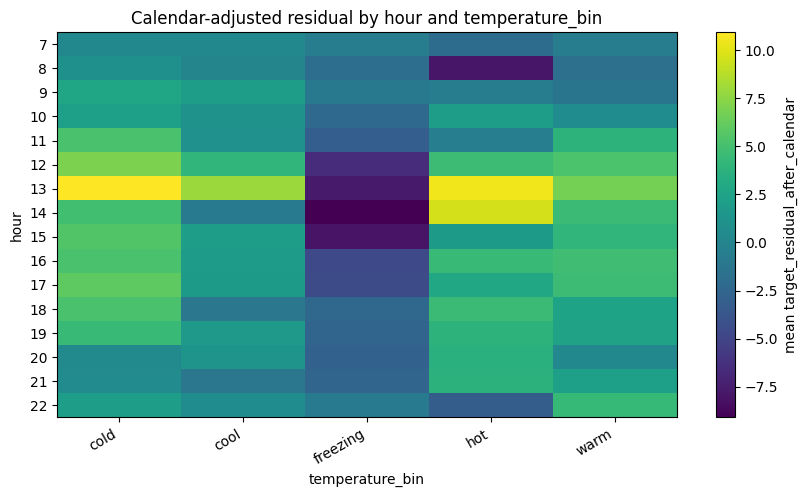

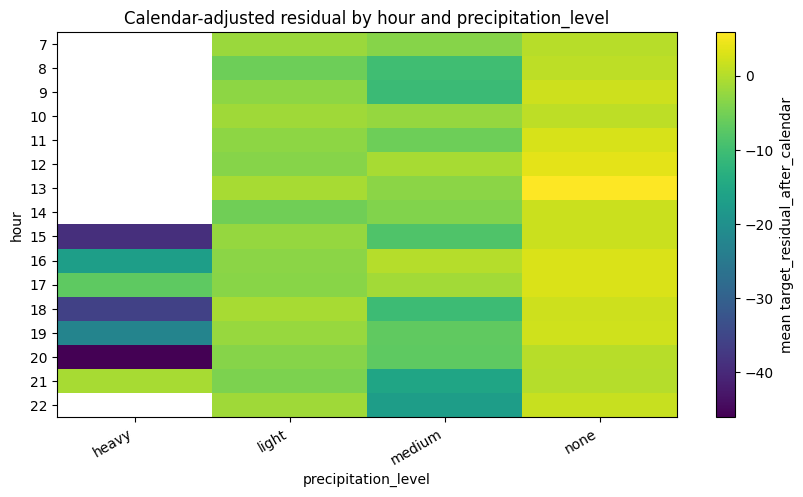

In [25]:
def heatmap_pivot(df, index_col, columns_col, value_col, title):
    pivot = df.pivot_table(
        index=index_col,
        columns=columns_col,
        values=value_col,
        aggfunc="mean",
    ).sort_index()

    plt.figure(figsize=(10, 5))
    plt.imshow(pivot.values, aspect="auto")
    plt.colorbar(label=f"mean {value_col}")
    plt.title(title)
    plt.xlabel(columns_col)
    plt.ylabel(index_col)
    plt.xticks(range(len(pivot.columns)), [str(c) for c in pivot.columns], rotation=30, ha="right")
    plt.yticks(range(len(pivot.index)), [str(i) for i in pivot.index])
    plt.show()

if "temperature_bin" in weather_df.columns:
    heatmap_pivot(
        weather_df,
        index_col="hour",
        columns_col="temperature_bin",
        value_col=TARGET_COL,
        title="Mean guests_count by hour and temperature_bin",
    )

if "precipitation_level" in weather_df.columns:
    heatmap_pivot(
        weather_df,
        index_col="hour",
        columns_col="precipitation_level",
        value_col=TARGET_COL,
        title="Mean guests_count by hour and precipitation_level",
    )

if "temperature_bin" in weather_df.columns:
    heatmap_pivot(
        weather_df,
        index_col="hour",
        columns_col="temperature_bin",
        value_col="target_residual_after_calendar",
        title="Calendar-adjusted residual by hour and temperature_bin",
    )

if "precipitation_level" in weather_df.columns:
    heatmap_pivot(
        weather_df,
        index_col="hour",
        columns_col="precipitation_level",
        value_col="target_residual_after_calendar",
        title="Calendar-adjusted residual by hour and precipitation_level",
    )

### 6. Общая корреляционная матрица по feature set из training notebook

Категориальные признаки здесь временно факторизуются числами только для EDA. Для модели это не меняет pipeline: в TFT они остаются categorical.

,feature,corr_with_guests_count
0,relative_humidity_2m,-0.373855
1,is_day,0.306992
2,long_weekend_day_number,-0.265607
3,hour_x_temperature,0.262629
4,temperature_2m,0.259846
5,temperature_bin,0.253601
6,is_weekend,-0.251893
7,production_day_type,-0.251893
8,is_official_day_off,-0.251893
9,apparent_temperature,0.237886


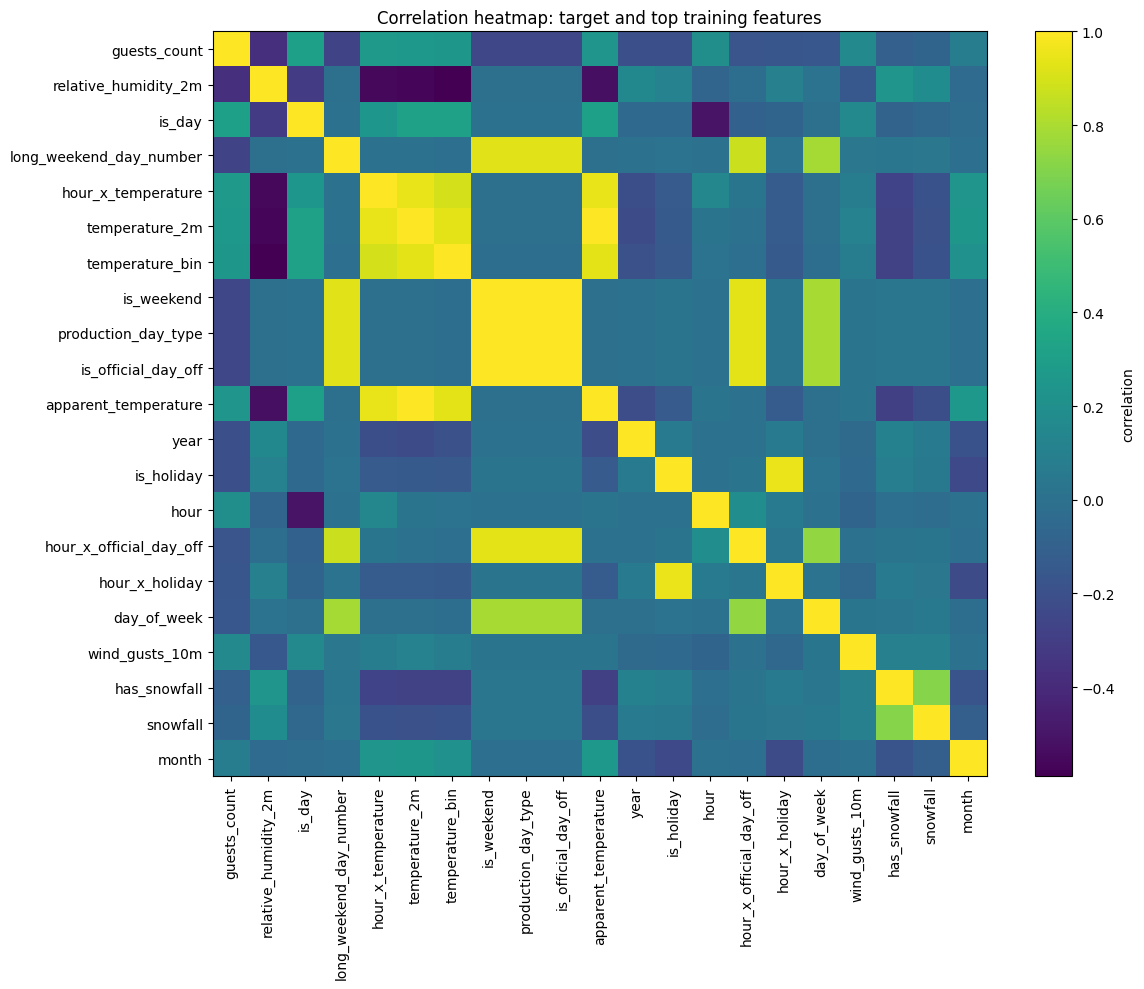

In [26]:
eda_cols = [c for c in TRAINING_FEATURES if c in weather_df.columns]
eda_matrix_df = weather_df[[TARGET_COL] + eda_cols].copy()

for col in eda_cols:
    if not pd.api.types.is_numeric_dtype(eda_matrix_df[col]):
        eda_matrix_df[col] = pd.factorize(eda_matrix_df[col].astype(str))[0]

corr = eda_matrix_df.corr(numeric_only=True)

# Покажем top features по абсолютной корреляции с target
target_corr = (
    corr[TARGET_COL]
    .drop(TARGET_COL)
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .reset_index()
)
target_corr.columns = ["feature", "corr_with_guests_count"]
display(target_corr.head(30))

top_cols = [TARGET_COL] + target_corr.head(20)["feature"].tolist()
corr_top = corr.loc[top_cols, top_cols]

plt.figure(figsize=(12, 10))
plt.imshow(corr_top.values, aspect="auto")
plt.colorbar(label="correlation")
plt.title("Correlation heatmap: target and top training features")
plt.xticks(range(len(corr_top.columns)), corr_top.columns, rotation=90)
plt.yticks(range(len(corr_top.index)), corr_top.index)
plt.tight_layout()
plt.show()

### 7. Вывод для презентации

Что демонстрирует этот анализ:

1. Погодные признаки действительно входят в training pipeline, поэтому их нужно показывать вместе с calendar/holiday features.
2. Сырые корреляции показывают общую связь таргета с погодой.
3. Calendar-adjusted residual показывает более честную зависимость: объясняет ли погода отклонение от типичного профиля `month × day_of_week × hour`.
4. Бины `temperature_bin` и `precipitation_level` удобны для презентации: они дают понятные бизнес-интерпретации, а не только численные корреляции.
5. Heatmap `hour × weather category` показывает, что эффект погоды может зависеть от времени суток. Это поддерживает идею использовать TFT/Transformer, который умеет работать с несколькими known future covariates и нелинейными взаимодействиями.

In [30]:
import pandas as pd
import numpy as np

datetime_col = "timestamp"
target_col = "guests_count"

df_holiday = df_clean.copy()
df_holiday[datetime_col] = pd.to_datetime(df_holiday[datetime_col])

# Берем только нормальные периоды, если такая колонка есть
if "period_type" in df_holiday.columns:
    df_holiday = df_holiday[df_holiday["period_type"] == "normal"].copy()

df_holiday["sale_date"] = df_holiday[datetime_col].dt.normalize()
df_holiday["hour"] = df_holiday[datetime_col].dt.hour
df_holiday["day_of_week"] = df_holiday[datetime_col].dt.dayofweek
df_holiday["month"] = df_holiday[datetime_col].dt.month
df_holiday["day_of_month"] = df_holiday[datetime_col].dt.day
df_holiday["weekofyear"] = df_holiday[datetime_col].dt.isocalendar().week.astype(int)
df_holiday["year"] = df_holiday[datetime_col].dt.year

# Федеральные праздники РФ
FEDERAL_HOLIDAY_NAMES = {
    (1, 1): "new_year",
    (1, 2): "new_year_holidays",
    (1, 3): "new_year_holidays",
    (1, 4): "new_year_holidays",
    (1, 5): "new_year_holidays",
    (1, 6): "new_year_holidays",
    (1, 7): "christmas",
    (1, 8): "new_year_holidays",
    (2, 23): "defender_day",
    (3, 8): "womens_day",
    (5, 1): "spring_labor_day",
    (5, 9): "victory_day",
    (6, 12): "russia_day",
    (11, 4): "unity_day",
}

# Упрощенный production calendar.
# Если в training notebook у тебя есть OFFICIAL_RU_CALENDAR_OVERRIDES, лучше взять его оттуда 1-в-1.
fixed_holiday_name = df_holiday["sale_date"].map(
    lambda x: FEDERAL_HOLIDAY_NAMES.get((x.month, x.day), "none")
)

is_fixed_federal_holiday = fixed_holiday_name.ne("none")
is_weekend = df_holiday["day_of_week"].isin([5, 6])

df_holiday["is_official_day_off"] = (is_weekend | is_fixed_federal_holiday).astype(int)
df_holiday["is_holiday"] = df_holiday["is_official_day_off"].astype(int)

# Предпраздничный день: день перед фиксированным федеральным праздником
next_day = df_holiday["sale_date"] + pd.Timedelta(days=1)
df_holiday["is_preholiday"] = next_day.map(
    lambda x: (x.month, x.day) in FEDERAL_HOLIDAY_NAMES
).astype(int)

df_holiday["is_shortened_day"] = df_holiday["is_preholiday"]
df_holiday["is_working_weekend"] = 0
df_holiday["is_transferred_day_off"] = 0

df_holiday["is_new_year_holidays"] = (
    (df_holiday["month"] == 1) &
    (df_holiday["day_of_month"].between(1, 8))
).astype(int)

df_holiday["is_moscow_city_holiday"] = 0

df_holiday["is_may_holidays_period"] = (
    ((df_holiday["month"] == 4) & (df_holiday["day_of_month"] >= 27)) |
    ((df_holiday["month"] == 5) & (df_holiday["day_of_month"] <= 12))
).astype(int)

df_holiday["holiday_name"] = fixed_holiday_name

df_holiday.loc[
    df_holiday["is_shortened_day"].eq(1) & df_holiday["holiday_name"].eq("none"),
    "holiday_name"
] = "shortened_day"

# Номер дня внутри майских праздников
may_mask = df_holiday["is_may_holidays_period"].eq(1)
unique_may_dates = sorted(df_holiday.loc[may_mask, "sale_date"].unique())

may_day_map = {
    date: i + 1
    for i, date in enumerate(unique_may_dates)
}

df_holiday["long_weekend_day_number"] = 0
df_holiday.loc[may_mask, "long_weekend_day_number"] = (
    df_holiday.loc[may_mask, "sale_date"].map(may_day_map).fillna(0).astype(int)
)

# Interaction-фичи, которые есть в training notebook
df_holiday["hour_x_holiday"] = df_holiday["hour"] * df_holiday["is_holiday"]
df_holiday["hour_x_preholiday"] = df_holiday["hour"] * df_holiday["is_preholiday"]
df_holiday["hour_x_new_year"] = df_holiday["hour"] * df_holiday["is_new_year_holidays"]
df_holiday["hour_x_may_holidays"] = df_holiday["hour"] * df_holiday["is_may_holidays_period"]

holiday_features = [
    "is_holiday",
    "is_preholiday",
    "is_shortened_day",
    "is_official_day_off",
    "is_working_weekend",
    "is_transferred_day_off",
    "is_new_year_holidays",
    "is_moscow_city_holiday",
    "is_may_holidays_period",
    "long_weekend_day_number",
    "hour_x_holiday",
    "hour_x_preholiday",
    "hour_x_new_year",
    "hour_x_may_holidays",
]

print("Holiday features created:")
print(holiday_features)

df_holiday[holiday_features].head()

Holiday features created:
['is_holiday', 'is_preholiday', 'is_shortened_day', 'is_official_day_off', 'is_working_weekend', 'is_transferred_day_off', 'is_new_year_holidays', 'is_moscow_city_holiday', 'is_may_holidays_period', 'long_weekend_day_number', 'hour_x_holiday', 'hour_x_preholiday', 'hour_x_new_year', 'hour_x_may_holidays']


,is_holiday,is_preholiday,is_shortened_day,is_official_day_off,is_working_weekend,is_transferred_day_off,is_new_year_holidays,is_moscow_city_holiday,is_may_holidays_period,long_weekend_day_number,hour_x_holiday,hour_x_preholiday,hour_x_new_year,hour_x_may_holidays
0,1,1,1,1,0,0,1,0,0,0,7,7,7,0
1,1,1,1,1,0,0,1,0,0,0,8,8,8,0
2,1,1,1,1,0,0,1,0,0,0,9,9,9,0
3,1,1,1,1,0,0,1,0,0,0,10,10,10,0
4,1,1,1,1,0,0,1,0,0,0,11,11,11,0


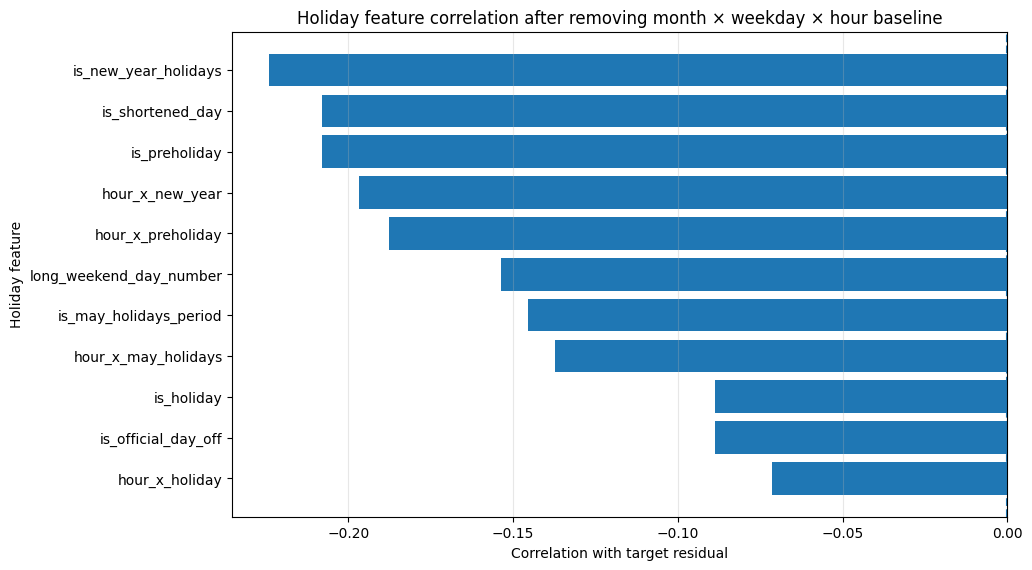

,correlation_with_target_residual
is_new_year_holidays,-0.223977
is_shortened_day,-0.208052
is_preholiday,-0.208052
hour_x_new_year,-0.196746
hour_x_preholiday,-0.187481
long_weekend_day_number,-0.153745
is_may_holidays_period,-0.145462
hour_x_may_holidays,-0.137312
is_holiday,-0.088546
is_official_day_off,-0.088546


In [31]:
import matplotlib.pyplot as plt

# Baseline: типичное значение для такого месяца, дня недели и часа
df_holiday["calendar_baseline"] = (
    df_holiday
    .groupby(["month", "day_of_week", "hour"])[target_col]
    .transform("median")
)

df_holiday["target_residual_after_calendar"] = (
    df_holiday[target_col] - df_holiday["calendar_baseline"]
)

corr_data = (
    df_holiday[
        ["target_residual_after_calendar"] + holiday_features
    ]
    .dropna()
)

holiday_corr = (
    corr_data
    .corr(numeric_only=True)["target_residual_after_calendar"]
    .drop("target_residual_after_calendar")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

plt.figure(figsize=(10, max(4, 0.45 * len(holiday_corr))))
plt.barh(holiday_corr.index[::-1], holiday_corr.values[::-1])
plt.axvline(0, linestyle="--")
plt.title("Holiday feature correlation after removing month × weekday × hour baseline")
plt.xlabel("Correlation with target residual")
plt.ylabel("Holiday feature")
plt.grid(axis="x", alpha=0.3)
plt.show()

display(
    holiday_corr
    .rename("correlation_with_target_residual")
    .to_frame()
)